# Multi-shot Variable-Density Spiral SE Diffusion

This notebook builds a multi-shot spin-echo diffusion sequence with a variable-density spiral readout in the local pSeq framework.

## Outline
1. Configure protocol and hardware limits.
2. Build RF/fat-sat and VDS spiral readout blocks.
3. Define diffusion directions.
4. Assemble the full multi-slice, multi-direction diffusion sequence.
5. Run timing QA and export the sequence.

## Design Notes
- VDS profile follows a constrained radial-spiral integration with gradient and slew limits.
- FOV profile is polynomial in normalized radius (`fov_coeff`).
- Interleaves are generated by rotating a base trajectory by `2*pi/n_shots`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import pypulseq as pp
from pSeq import (
    pSeq_Base,
    pSeq_RF,
    pSeq_FatSat,
    pSeq_Diffusion,
    pSeq_Spiral_VDS,
    pSeq_GRE_multi_echo
)

In [2]:
# ------------------------------
# User-facing protocol parameters
# ------------------------------
fov = 210e-3
nx = 140
ny = 140
n_shots = 6

# Spiral acceleration factor (in-plane undersampling).
# Typical useful range for blur reduction: 2.0 - 4.0
# spiral_accel = 2.0
# spiral_accel = 1.5
spiral_accel = 1.0
adc_dwell_s = 1e-6

# Variable-density FOV profile: F(r) = fov * (c0 + c1*x + c2*x^2 + ...), x=r/rmax
# Keep profile positive over x in [0, 1].
fov_coeff = [1.0, 0.0, -0.35]

n_slices = 3
slice_thickness = 5e-3
slice_gap = 10e-3
slice_offsets = (np.arange(n_slices) - (n_slices - 1) / 2.0) * (slice_thickness + slice_gap)

# num_repeats = 8
num_repeats = 4
TR_sec = 500e-3
b_value = 2000
# b_value = 2000
# b_value = 10000

# Optional shot-level spoiling for residual transverse cleanup.
enable_rf_spoil = False
rf_spoil_inc_deg = 117.0
enable_grad_spoil = True
grad_spoil_cycles_per_voxel = 20.0

print(f'FOV={fov*1e3:.1f} mm, Matrix={nx}x{ny}, Shots={n_shots}')
print(f'Spiral acceleration={spiral_accel:.2f}x')
print(f'FOV coeff={fov_coeff}')
print(f'Slices={n_slices}, Repeat={num_repeats}, b={b_value} s/mm^2')
print(f'RF spoil={enable_rf_spoil} (inc={rf_spoil_inc_deg:.1f} deg)')
print(f'Grad spoil={enable_grad_spoil} (cycles/voxel={grad_spoil_cycles_per_voxel:.1f})')

FOV=210.0 mm, Matrix=140x140, Shots=6
Spiral acceleration=1.00x
FOV coeff=[1.0, 0.0, -0.35]
Slices=3, Repeat=4, b=2000 s/mm^2
RF spoil=False (inc=117.0 deg)
Grad spoil=True (cycles/voxel=20.0)


In [3]:
# --------------------------------------------------------
# Build hardware limits and reusable RF/FatSat blocks
# --------------------------------------------------------
system_max = pp.Opts(
    max_grad=200, grad_unit='mT/m',
    max_slew=200, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

# system_diff = pp.Opts(
#     max_grad=160, grad_unit='mT/m',
#     max_slew=80, slew_unit='T/m/s',
#     rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
# )
system_diff = pp.Opts(
    max_grad=200, grad_unit='mT/m',
    max_slew=70, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_spiral = pp.Opts(
    max_grad=100, grad_unit='mT/m',
    max_slew=70, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_rf = pp.Opts(
    max_grad=100, grad_unit='mT/m',
    max_slew=50, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_low = pp.Opts(
    max_grad=30, grad_unit='mT/m',
    max_slew=30, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

seq_sp = pSeq_Base(system=system_max)

fatsat = pSeq_FatSat(system=system_low, type='FatSat2')
fatsat.prep_fatsat()

rf90 = pSeq_RF(
    system=system_rf,
    flip_angle=np.pi / 2,
    duration=3e-3,
    thickness=slice_thickness,
    use='excitation',
)
rf90.prep()

rf180 = pSeq_RF(
    system=system_rf,
    flip_angle=np.pi,
    duration=6e-3,
    thickness=slice_thickness,
    use='refocusing',
    do_refocus=False,
    crusher_area=1000,
    # crusher_axis=['x', 'y', 'z'],
    crusher_axis=['z'],
)
rf180.prep()

trig = pp.make_digital_output_pulse('ext1', duration=20e-6)

-220.3308
0.003 0.003
-220.3308
Fat Sat: The peak rf_fs Amplitude =  1.6253962983488777e-06 uT
Making Sinc Pulse with flip angle 90.0
Making SLR Pulse with flip angle 90.0


e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_FatSat.py:36: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  self.rf_fs = pp.make_gauss_pulse(110 * np.pi / 180, system=self.system, duration=8e-3,
e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_RF.py:64: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  self.rf, self.gz, self.gzReph = pp.make_sinc_pulse(flip_angle = self.flip_angle,
c:\Users\bughh\.conda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


excitation : The peak rf Amplitude =  7.797889527969152 uT
Making Sinc Pulse with flip angle 180.0
Making SLR Pulse with flip angle 180.0
refocusing : The peak rf Amplitude =  7.797889596354154 uT
Prepared crusher gradients for refocusing pulse on ['z']-axis with area 1000 1/m


e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_RF.py:80: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rfp,gz,gzr = make_sigpy_pulse.sigpy_n_seq(flip_angle = self.flip_angle,  freq_offset = 0, phase_offset = self.phase_offset,
e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_RF.py:64: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  self.rf, self.gz, self.gzReph = pp.make_sinc_pulse(flip_angle = self.flip_angle,


Spiral summary: {'adc_samples': 14008, 'adc_dwell': 1e-06, 'adc_bandwidth_hz': 1000000.0, 'center_hold_duration': 3.0000000000000004e-05, 'accel_requested': 1.0, 'accel_effective': 1.0, 'readout_duration': 0.01403, 'rampdown_duration': 0.00033000000000000043, 'rewinder_duration': 0.00062, 'shot_duration': 0.014980000000000002, 'kmax': 333.33333333333337}
Readout duration per shot: 14.03 ms
Total shot duration (with rewinder): 14.98 ms


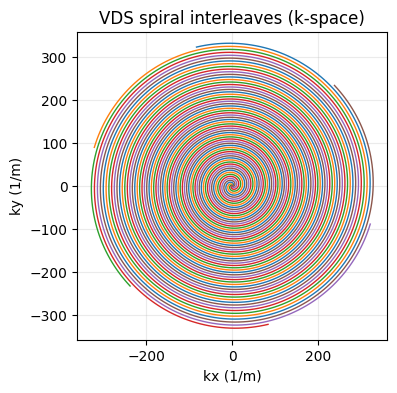

In [4]:
# --------------------------------------------------------
# Prepare multishot variable-density spiral readout
# --------------------------------------------------------
spiral_vds = pSeq_Spiral_VDS(
    system=system_spiral,
    fov=fov,
    nx=nx,
    ny=ny,
    n_interleaves=n_shots,
    fov_coeff=fov_coeff,
    accel=spiral_accel,
    oversamp=4,
)
summary = spiral_vds.prep(adc_dwell=adc_dwell_s)
print('Spiral summary:', summary)
print(f"Readout duration per shot: {summary['readout_duration']*1e3:.2f} ms")
print(f"Total shot duration (with rewinder): {summary['shot_duration']*1e3:.2f} ms")

k0 = spiral_vds.get_ktraj(interleaf=0)
plt.figure(figsize=(4, 4))
for shot_idx in range(n_shots):
    ks = spiral_vds.get_ktraj(interleaf=shot_idx)
    plt.plot(np.real(ks), np.imag(ks), lw=1.0, label=f'Shot {shot_idx}')
plt.title('VDS spiral interleaves (k-space)')
plt.xlabel('kx (1/m)')
plt.ylabel('ky (1/m)')
plt.axis('equal')
plt.grid(True, alpha=0.25)
# plt.legend(bbox_to_anchor=(1,1.1))
# plt.xlim(-1,1)
# plt.ylim(-1,1)
plt.show()

In [5]:
# -------------------------------------------------------------
# Fixed diffusion direction set (b0 + 6 cardinal directions)
# -------------------------------------------------------------
diff_dirs = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [-1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, -1.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 0.0, -1.0],
], dtype=float)

dir_labels = ['b0', 'x+', 'x-', 'y+', 'y-', 'z+', 'z-']
num_dirs = diff_dirs.shape[0]
print('Using diffusion directions:', dir_labels)

Using diffusion directions: ['b0', 'x+', 'x-', 'y+', 'y-', 'z+', 'z-']


In [6]:
# ---------------------------------------------------------------------
# Sequence assembly (multi-slice diffusion with multishot VDS spiral)
# Loop order: repeat -> slice -> direction -> shot
# ---------------------------------------------------------------------
seq_sp = pSeq_Base(system=system_max)

diffusion = pSeq_Diffusion(
    system=system_diff,
    channel='x',
    target_b_s_mm2=b_value,
    max_lobe_duration=40e-3,
)

_ = diffusion.prep_monopolar(
    rf90=rf90,
    rf180=rf180,
    epi=spiral_vds,
    extra_pre_delay_s=0.0,
    verbose=True,
)

print(f'Designed diffusion b(actual): {diffusion.b_actual_s_mm2:.2f} s/mm^2')
print(f'Designed TE(min): {diffusion.te*1e3:.2f} ms')

# --- Shot-level spoiler gradients (optional) ---
grad_spoil_area_per_shot = grad_spoil_cycles_per_voxel / slice_thickness
if enable_grad_spoil:
    grad_spoiler_x = pp.make_trapezoid(channel='x', system=system_low, area=grad_spoil_area_per_shot)
    grad_spoiler_y = pp.make_trapezoid(channel='y', system=system_low, area=grad_spoil_area_per_shot)
    grad_spoiler_z = pp.make_trapezoid(channel='z', system=system_low, area=grad_spoil_area_per_shot)

rf_spoiler_phase_deg = 0.0
rf_spoiler_increment_state_deg = 0.0

total_shots = 0
tr_violations = 0

for slc_idx, slc_offset in tqdm(enumerate(slice_offsets), desc='Slices'):
    for dir_idx, diff_dir in enumerate(diff_dirs):
        for rep in range(num_repeats):
            for shot_idx in range(n_shots):
                total_shots += 1
                t_start = seq_sp.seq.duration()[0] if len(seq_sp.seq.block_events) > 0 else 0.0

                rf90.offset_rf(offset=slc_offset)
                rf180.offset_rf(offset=slc_offset)
                if enable_rf_spoil:
                    rf_spoiler_phase_deg = (rf_spoiler_phase_deg + rf_spoiler_increment_state_deg) % 360.0
                    rf_spoiler_increment_state_deg = (rf_spoiler_increment_state_deg + rf_spoil_inc_deg) % 360.0
                    rf_spoiler_phase_rad = np.deg2rad(rf_spoiler_phase_deg)
                    rf90.rf.phase_offset += rf_spoiler_phase_rad
                    rf180.rf.phase_offset += rf_spoiler_phase_rad
                    spiral_vds.adc.phase_offset = rf90.rf.phase_offset

                label_rep = pp.make_label(type='SET', label='REP', value=rep)
                label_slc = pp.make_label(type='SET', label='SLC', value=slc_idx)
                label_seg = pp.make_label(type='SET', label='SEG', value=dir_idx)
                label_avg = pp.make_label(type='SET', label='AVG', value=shot_idx)
                seq_sp.seq.add_block(label_rep, label_slc, label_seg, label_avg, trig)

                # Get rotated diffusion gradient lobes for this direction.
                # diff_lobe_pre : gradients before 180° refocusing pulse
                # diff_lobe_post: gradients after 180° refocusing pulse
                diff_lobe_pre, diff_lobe_post = diffusion.get_rotated_lobes(diff_dir)

                # seq_sp.add_pseq_to_self(fatsat)
                seq_sp.add_pseq_to_self(rf90)
                seq_sp.seq.add_block(*diff_lobe_pre)

                if diffusion.delay1 > 0:
                    seq_sp.seq.add_block(pp.make_delay(diffusion.delay1))

                seq_sp.add_pseq_to_self(rf180)
                seq_sp.seq.add_block(*diff_lobe_post)

                if diffusion.delay2 > 0:
                    seq_sp.seq.add_block(pp.make_delay(diffusion.delay2))

                spiral_vds.add_to_seq(seq_sp, interleaf=shot_idx, label=False, add_rewinder=True)
                if enable_grad_spoil:
                    seq_sp.seq.add_block(grad_spoiler_x, grad_spoiler_y, grad_spoiler_z)

                t_end = seq_sp.seq.duration()[0]
                shot_dur = t_end - t_start
                tr_pad = TR_sec - shot_dur

                if tr_pad > system_max.grad_raster_time:
                    tr_pad = np.ceil(tr_pad / system_max.grad_raster_time) * system_max.grad_raster_time
                    seq_sp.seq.add_block(pp.make_delay(tr_pad))
                elif tr_pad < -1e-6:
                    tr_violations += 1

print(f'Total shots added: {total_shots}')
print(f'TR violations: {tr_violations}')
print(f'Estimated sequence duration: {seq_sp.seq.duration()[0]:.2f} s')

Diffusion designer summary:
  target b: 2000.00 s/mm^2
  actual b: 2000.00 s/mm^2
  lobe amplitude: 8507725.465 Hz/m
  lobe duration: 9.050 ms
  delay1: 0.000 ms
  delay2: 2.550 ms
  pre-lobe delay: 2.529 ms
  inter-lobe delay: 11.480 ms
  TE(min): 32.139 ms
  spin-echo mismatch: -9.500 us
Designed diffusion b(actual): 2000.00 s/mm^2
Designed TE(min): 32.14 ms


Slices: 0it [00:00, ?it/s]

Total shots added: 504
TR violations: 0
Estimated sequence duration: 252.00 s


Timing check passed: True
Total sequence duration: 252.001 s


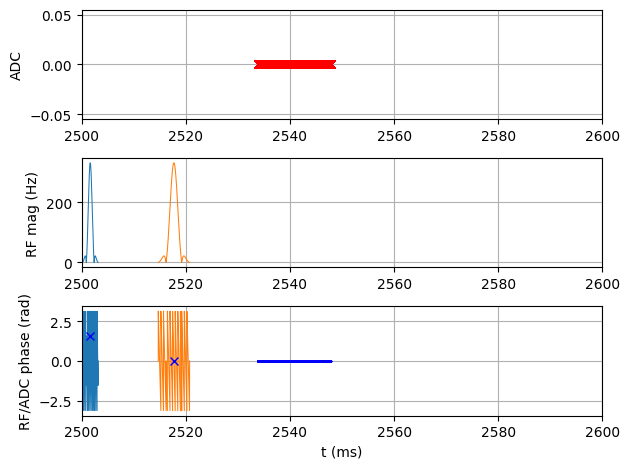

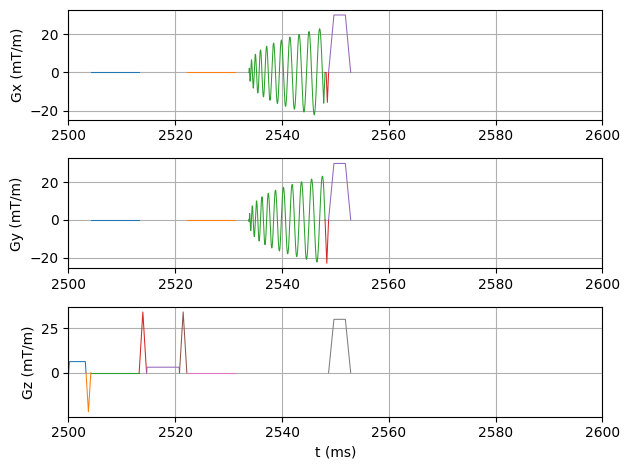

In [7]:
# ---------------------------------------
# Timing QA and quick visual inspection
# ---------------------------------------
ok, err = seq_sp.seq.check_timing()
print(f'Timing check passed: {ok}')
if not ok:
    print('First timing issues:')
    for item in err[:10]:
        print(' -', item)

print(f'Total sequence duration: {seq_sp.seq.duration()[0]:.3f} s')
seq_sp.seq.plot(time_range=[TR_sec*5, TR_sec*5 + 100e-3], grad_disp='mT/m', time_disp='ms')
plt.show()

In [8]:
# -----------------------------
# Export sequence to .seq file
# -----------------------------
# version = 'v0.7.2-highres'
# version = 'v0.7.2-highres-skope'
version = 'v0.9.2'
out_dir = Path('seq')
out_dir.mkdir(parents=True, exist_ok=True)
accel_tag = str(spiral_accel)
out_name = (
    f'fs_se_dti_spiral_vds_b{int(b_value)}_'
    f'dir{num_dirs}_shot{n_shots}_slice{n_slices}_'
    f'acc{accel_tag}_{version}.seq'
)
out_path = out_dir / out_name

# seq_sp.seq.write(str(out_path))
print(f'Wrote sequence: {out_path}')

# Optional safety check: keep disabled by default to avoid long runtime.
run_safety_check = True
if run_safety_check:
    seq_sp.check_safety_lims(
        r'E:\\MGH\\Healthy_Grad\\asc\\CimaX.asc',
        time_range=[0, min(TR_sec, seq_sp.seq.duration()[0])],
        cns=True,
        do_plot=False,
    )
    print('Safety check complete.')

Wrote sequence: seq\fs_se_dti_spiral_vds_b2000_dir7_shot6_slice3_acc1.0_v0.9.2.seq
PNS is OK
CNS is OK
Safety check complete.


In [9]:
# ------------------------------------------------------------------
# Multi-echo FLASH (GRE) sensitivity mapping sequence (new pSeq_Base)
# Geometry is matched to diffusion EPI: FOV, in-plane matrix, slices.
# ------------------------------------------------------------------
system_gre = pp.Opts(
    max_grad=120, grad_unit='mT/m',
    max_slew=100, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

seq_meflash = pSeq_Base(system=system_gre)
seq_meflash.init_seq()

gre_sens = pSeq_GRE_multi_echo(
    system=system_gre,
    fov=fov,
    nx=nx,
    ny=ny,
    slice_thickness=slice_thickness,
    flip_angle=np.deg2rad(5.0),
    rf_duration=0.8e-3,
    readout_time=1.28e-3,
    te1=2.46e-3,
    echo_spacing=2.46e-3,
    # echo_spacing=3.2e-3,
    tr=50e-3,
    n_echoes=4,
    readout_mode='monopolar',
    rf_spoil_inc_deg=117.0,
    spoiler_area_ro=1.0 / 1e-3,
    spoiler_area_pe=1.0 / 1e-3,
    spoiler_area_sl=1.0 / 1e-3,
 )
gre_sens.prep()

for rep_idx in range(1):
    for slc_idx, slc_offset in enumerate(slice_offsets):
        for lin_idx in range(ny):
            gre_sens.add_line_to_seq(
                seq_meflash,
                line_index=lin_idx,
                slice_offset=slc_offset,
                rep_idx=rep_idx,
                slc_idx=slc_idx,
                label=True,
            )

ok_me, err_me = seq_meflash.seq.check_timing()
print(f'ME-FLASH timing check passed: {ok_me}')
if not ok_me:
    print('First timing issues:')
    for item in err_me[:10]:
        print(' -', item)

me_timing = gre_sens.get_timing()
print(f"ME-FLASH nominal TR: {me_timing['tr_nominal']*1e3:.3f} ms")
print(f"TEs [ms]: {np.round((me_timing['te1'] + np.arange(me_timing['n_echoes']) * me_timing['echo_spacing']) * 1e3, 3)}")

Prepared multi-echo FLASH blocks:
  Matrix: 140x140, FOV: 210.0 mm
  Readout mode: monopolar
  Inter-echo rewind (constrained): 0.920 ms
  Inter-echo delay block: 0.000 ms
  Echoes: 4, TE1: 2.46 ms, dTE: 2.46 ms
  TR: 50.00 ms, TR fill: 37.17 ms


e:\MGH\MRI_Diffusion_ACDC_EddyCurrent_Correction\imaging\pSeq\pSeq_GRE_multi_echo.py:91: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  self.rf, self.gz, self.gz_reph = pp.make_sinc_pulse(


ME-FLASH timing check passed: True
ME-FLASH nominal TR: 50.000 ms
TEs [ms]: [2.46 4.92 7.38 9.84]


Wrote ME-FLASH sequence: seq\meflash_fov210_mat140x140_slc3_thk5_echo4_v0.9.1-midres.seq
PNS is OK
CNS is OK


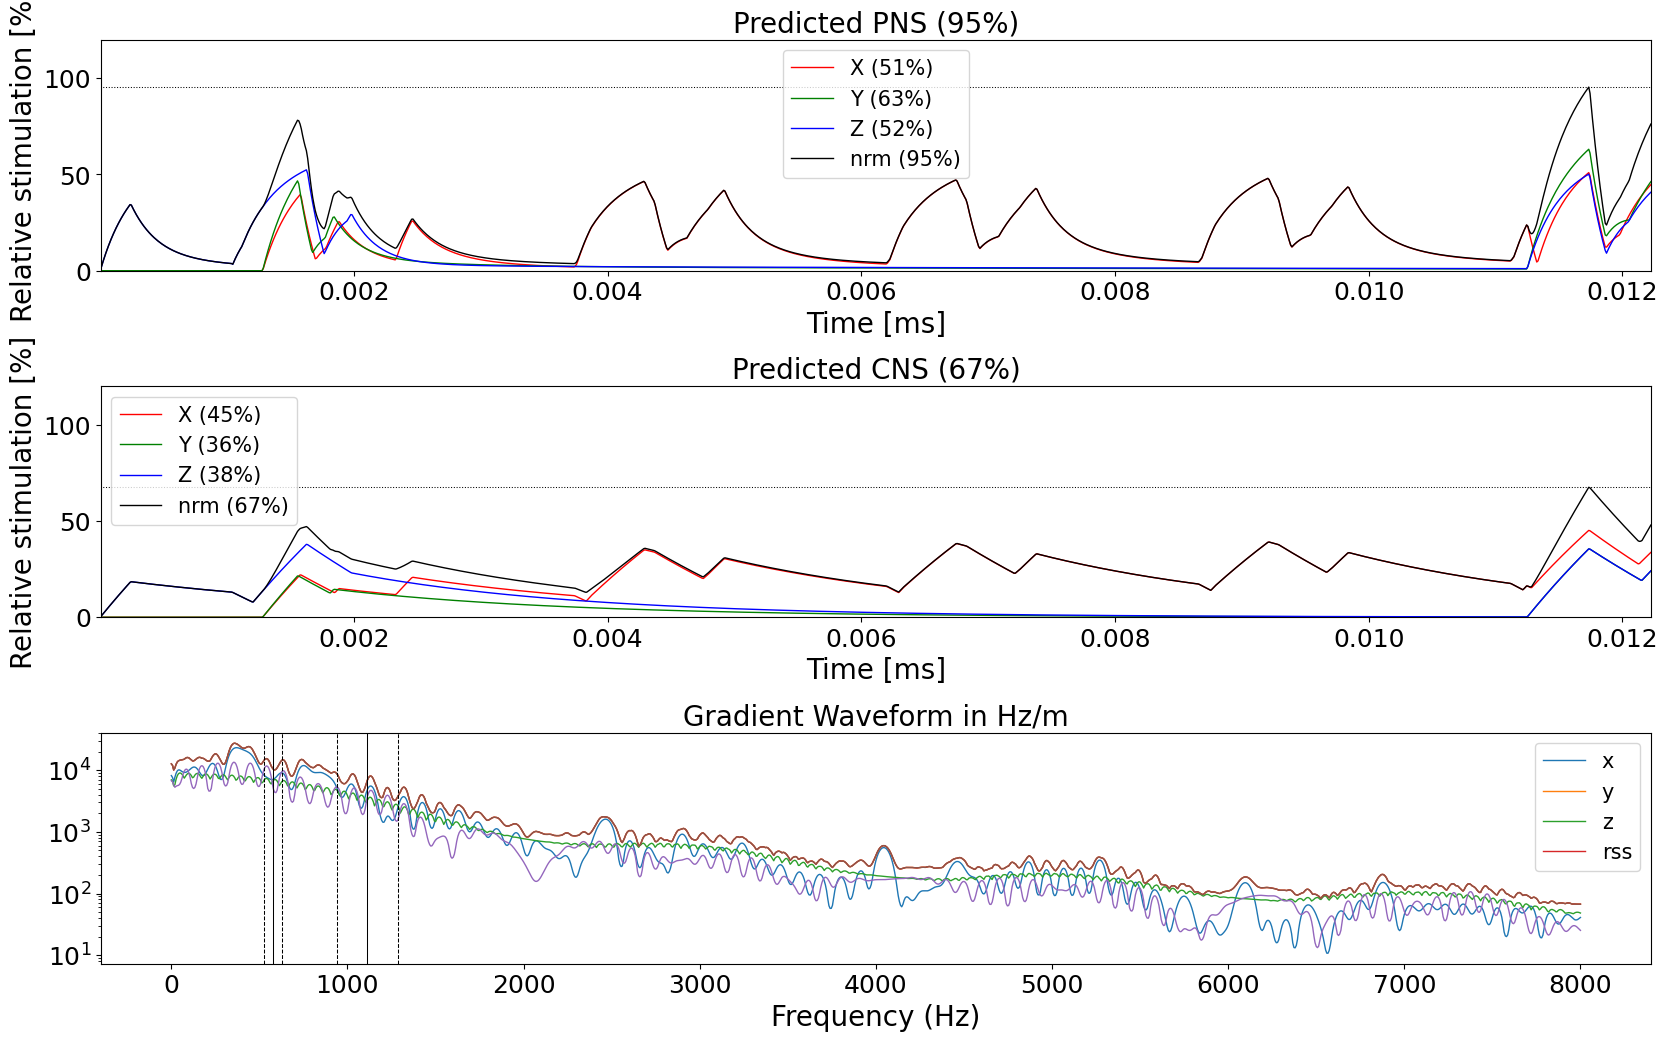

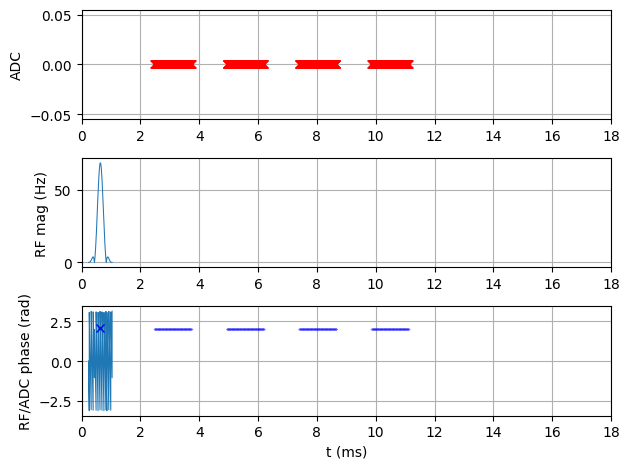

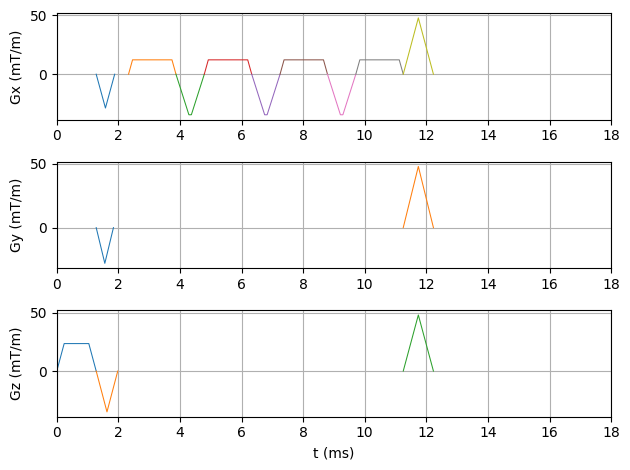

In [10]:
meflash_version = 'v0.9.1-midres'
meflash_out_dir = Path('seq')
meflash_out_dir.mkdir(parents=True, exist_ok=True)
meflash_name = (
    f'meflash_fov{int(fov*1e3)}_'
    f'mat{nx}x{ny}_slc{n_slices}_thk{int(slice_thickness*1e3)}_'
    f'echo{me_timing["n_echoes"]}_{meflash_version}.seq'
 )
meflash_path = meflash_out_dir / meflash_name
# seq_meflash.seq.write(str(meflash_path))
print(f'Wrote ME-FLASH sequence: {meflash_path}')

seq_meflash.check_safety_lims(r'E:\MGH\Healthy_Grad\asc\CimaX.asc', time_range=[0, 21e-3], cns=True, do_plot=True)
seq_meflash.seq.plot(time_disp='ms', grad_disp='mT/m', time_range=[0, 18e-3])

## Twix-Based Spiral NUFFT Reconstruction

This section reconstructs the acquired spiral diffusion Twix data with SigPy NUFFT-SENSE.

Pipeline:
1. Load meflash Twix and estimate slice-wise ESPIRiT coil sensitivity maps.
2. Load spiral diffusion Twix and reorder into canonical `(rep, slc, dir, shot, ch, ro)`.
3. Build NUFFT coordinates from the designed spiral trajectory interleaves.
4. Run direct SENSE reconstruction for each `(rep, slc, dir)`.

In [11]:
from tqdm.auto import tqdm
from scipy.fft import fftshift, ifftshift, ifft2
import sigpy as sp
from sigpy.mri.app import EspiritCalib
from twixtools import read_twix, map_twix


def _ifftc2_local(ksp):
    return fftshift(ifft2(ifftshift(ksp, axes=(-2, -1)), axes=(-2, -1), norm='ortho'), axes=(-2, -1))


def _safe_get_twix_image_obj(mapped_obj):
    if isinstance(mapped_obj, list) and len(mapped_obj) > 0:
        mapped_obj = mapped_obj[-1]
    if isinstance(mapped_obj, dict) and 'image' in mapped_obj:
        return mapped_obj['image']
    raise RuntimeError('Mapped twix object does not contain a readable image block.')


def _infer_axes_from_twix_dims(img_obj, raw_shape, role_candidates, role_expected_sizes=None):
    dims = tuple(getattr(img_obj, 'dims', ()))
    full_shape = tuple(getattr(img_obj, 'shape', ()))
    if len(dims) == 0 or len(full_shape) != len(dims):
        return None

    # Prefer unsqueezed arrays. Keep a legacy path for already-squeezed arrays.
    if len(raw_shape) == len(dims):
        dim_labels = list(dims)
    else:
        non_singleton_dims = [d for d, s in zip(dims, full_shape) if int(s) > 1]
        if len(raw_shape) != len(non_singleton_dims):
            return None
        dim_labels = non_singleton_dims

    dim_to_axes = {}
    for axis, dim_name in enumerate(dim_labels):
        dim_to_axes.setdefault(dim_name, []).append(axis)

    axis_map = {}
    used_axes = set()
    for role, candidates in role_candidates.items():
        role_axes = []
        for d in candidates:
            role_axes.extend([ax for ax in dim_to_axes.get(d, []) if ax not in used_axes])

        if len(role_axes) == 0:
            return None

        hit = None
        if role_expected_sizes is not None and role in role_expected_sizes and role_expected_sizes[role] is not None:
            target_size = int(role_expected_sizes[role])
            size_matches = [ax for ax in role_axes if int(raw_shape[ax]) == target_size]
            if len(size_matches) == 1:
                hit = size_matches[0]
            elif len(size_matches) > 1:
                # Prefer non-singleton axis when expected size appears multiple times.
                non_single = [ax for ax in size_matches if int(raw_shape[ax]) > 1]
                hit = non_single[0] if len(non_single) > 0 else size_matches[0]

        if hit is None:
            hit = role_axes[0]

        axis_map[role] = hit
        used_axes.add(hit)
    return axis_map


def _infer_axis_map_first_dims(shape, expected):
    axis_map = {}
    used = set()
    for key, size in expected.items():
        if size is None:
            continue
        matches = [i for i, s in enumerate(shape) if int(s) == int(size) and i not in used]
        if len(matches) == 1:
            axis_map[key] = matches[0]
            used.add(matches[0])
    return axis_map


def _extract_roles_from_raw(raw, axis_map, ordered_roles, context_name='twix'):
    axes = [int(axis_map[r]) for r in ordered_roles]
    if len(set(axes)) != len(axes):
        raise RuntimeError(f'{context_name}: duplicate axes in role map: {axis_map}')

    arr = np.moveaxis(raw, axes, np.arange(len(ordered_roles)))
    extra_shape = arr.shape[len(ordered_roles):]

    # Any unmapped dimensions must be singleton so they can be safely dropped.
    if any(int(s) != 1 for s in extra_shape):
        raise RuntimeError(
            f'{context_name}: found unmapped non-singleton axes {extra_shape}; '
            f'axis_map={axis_map}, raw_shape={raw.shape}'
        )

    if len(extra_shape) > 0:
        arr = arr.reshape(arr.shape[:len(ordered_roles)])

    return arr


def _center_crop_or_pad_2d(arr, target_y, target_x):
    out = np.zeros(arr.shape[:-2] + (target_y, target_x), dtype=arr.dtype)
    src_y, src_x = arr.shape[-2], arr.shape[-1]

    copy_y = min(src_y, target_y)
    copy_x = min(src_x, target_x)

    src_y0 = (src_y - copy_y) // 2
    src_x0 = (src_x - copy_x) // 2
    dst_y0 = (target_y - copy_y) // 2
    dst_x0 = (target_x - copy_x) // 2

    out[..., dst_y0:dst_y0 + copy_y, dst_x0:dst_x0 + copy_x] = arr[..., src_y0:src_y0 + copy_y, src_x0:src_x0 + copy_x]
    return out


# Try GPU first; if unavailable, use CPU.
try:
    _sp_device = sp.Device(0)
    _ = _sp_device.xp.zeros(1)
except Exception:
    _sp_device = sp.Device(-1)

print('SigPy reconstruction device:', _sp_device)

SigPy reconstruction device: <CUDA Device 0>


In [12]:
# b0_path = Path('scan_data/meas_MID00243_FID16403_meflash_fov200_mat160_slc3_thk5_echo4_v0_2_0.dat')
# b0_path = Path('scan_data/meas_MID00374_FID16534_meflash_fov200_mat256_slc3_thk5_echo4_v0_3_0_highres.dat')
# b0_path = Path('scan_data/meas_MID00389_FID16549_meflash_fov200_mat256x256_slc3_thk5_echo4_v0_3_2_highres.dat') # Manoe's phantom
# b0_path = Path('scan_data/meas_MID00231_FID16931_meflash_fov200_mat256x256_slc3_thk5_echo4_v0_3_3_highres.dat')
# b0_path = Path('scan_data/meas_MID00274_FID16974_meflash_fov200_mat256x256_slc3_thk5_echo4_v0_3_3_highres.dat')
# b0_path = Path(r'scan_data\2026_0423_ACDC\meas_MID00495_FID17203_meflash_fov210_mat256x256_slc3_thk5_echo4_v0_4_0_highres.dat')
# b0_path = Path(r'scan_data\2026_0423_RedHead\meas_MID00536_FID17243_meflash_fov210_mat256x256_slc3_thk5_echo4_v0_4_0_highres.dat')
# b0_path = Path(r'scan_data\2026_0425_Bay2\meas_MID00049_FID25431_meflash_fov210_mat140_slc3_thk5_echo4_v0_9_0.dat')
# b0_path = Path(r'scan_data\2026_0427_Bay5\meas_MID00364_FID17963_meflash_fov210_mat140x140_slc3_thk5_echo4_v0_9_1_midres.dat')
# b0_path = Path(r'scan_data\2026_0427_Bay5\meas_MID00375_FID17974_meflash_fov210_mat140x140_slc3_thk5_echo4_v0_9_1_midres.dat')
b0_path = Path(r'scan_data\2026_0429_Bay5\meas_MID00447_FID18547_meflash_fov210_mat140x140_slc3_thk5_echo4_v0_9_1_midres.dat')

# spiral_path = Path('scan_data/meas_MID00240_FID16400_fs_se_dti_spiral_vds_b2000_dir7_shot16_slice3_acc8_v0_4_1.dat')
# spiral_path = Path('scan_data/meas_MID00249_FID16409_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc8_v0_5_0.dat')
# spiral_path = Path('scan_data/meas_MID00253_FID16413_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc1_v0_6_0.dat')
# spiral_path = Path('scan_data/meas_MID00254_FID16414_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc1_5_v0_6_0.dat')
# spiral_path = Path('scan_data/meas_MID00252_FID16412_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc2_v0_6_0.dat')
# spiral_path = Path('scan_data/meas_MID00388_FID16548_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_v0_7_2_highres.dat') # Manoe's phantom
# spiral_path = Path('scan_data/meas_MID00229_FID16929_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_7_2_skope.dat') # 
# spiral_path = Path('scan_data/meas_MID00230_FID16930_fs_se_dti_spiral_vds_b10000_dir7_shot40_slc3_acc1_0_v0_7_3_skop.dat') # 
# spiral_path = Path('scan_data/meas_MID00232_FID16932_fs_se_dti_spiral_vds_b10000_dir7_shot40_slc3_acc1_0_v0_7_3_skop.dat') # 
# spiral_path = Path('scan_data/meas_MID00242_FID16942_fs_se_dti_spiral_vds_b10000_dir7_shot40_slc3_acc1_0_v0_7_3_skop.dat') # 
# spiral_path = Path('scan_data/meas_MID00275_FID16975_fs_se_dti_spiral_vds_b10000_dir7_shot40_slc3_acc1_0_v0_7_3_skop.dat')
# spiral_path = Path('scan_data/meas_MID00276_FID16976_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_7_2_skope.dat')

# spiral_path = Path(r'scan_data\2026_0423\meas_MID00501_FID17209_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_2_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423\meas_MID00502_FID17210_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_3_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423\meas_MID00503_FID17211_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_4_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423\meas_MID00505_FID17213_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_5_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423\meas_MID00507_FID17215_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_6_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423_ACDC\meas_MID00514_FID17222_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_7_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423_RedHead\meas_MID00537_FID17244_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_7_skope.dat')

# spiral_path = Path(r'scan_data\2026_0423_RedHead\meas_MID00538_FID17245_fs_se_dti_spiral_vds_b200_dir7_shot40_slc3_acc1_0_v0_8_7_skope.dat')

# spiral_path = Path(r'scan_data\2026_0425_Bay2\meas_MID00055_FID25437_fs_se_dti_spiral_vds_b2000_dir7_shot3_slice3_acc1_0_v0_9_0.dat')
# spiral_path = Path(r'scan_data\2026_0427_Bay5\meas_MID00365_FID17964_fs_se_dti_spiral_vds_b2000_dir7_shot8_slice3_acc1_0_v0_9_1.dat')
# spiral_path = Path(r'scan_data\2026_0427_Bay5\meas_MID00376_FID17975_fs_se_dti_spiral_vds_b2000_dir7_shot6_slice3_acc1_0_v0_9_1.dat')
spiral_path = Path(r'scan_data\2026_0429_Bay5\meas_MID00449_FID18549_fs_se_dti_spiral_vds_b2000_dir7_shot6_slice3_acc1_0_v0_9_2.dat')

In [13]:
# ------------------------------------------------------------------
# Step 1: Load meflash Twix and estimate ESPIRiT sensitivity maps
# ------------------------------------------------------------------
if not b0_path.exists():
    raise FileNotFoundError(f'Could not find b0 Twix file: {b0_path}')

b0_twix_raw_data = read_twix(str(b0_path), parse_pmu=False)
b0_twix_mapped_data = map_twix(b0_twix_raw_data)
b0_image_object = _safe_get_twix_image_obj(b0_twix_mapped_data)
b0_raw_data = np.asarray(b0_image_object[:])
print('Raw b0 image shape:', b0_raw_data.shape)

b0_axis_mapping = _infer_axes_from_twix_dims(
    b0_image_object,
    b0_raw_data.shape,
    role_candidates={
        'slc': ('Sli', 'Set'),
        'echo': ('Eco',),
        'ky': ('Lin',),
        'ch': ('Cha',),
        'kx': ('Col',),
    },
)

if b0_axis_mapping is not None:
    print('B0 axis map from TWIX header dims:', b0_axis_mapping)
    b0_kspace = _extract_roles_from_raw(
        b0_raw_data,
        b0_axis_mapping,
        ordered_roles=('slc', 'echo', 'ky', 'ch', 'kx'),
        context_name='b0',
    ).astype(np.complex64, copy=False)
else:
    # Fallback: assume (slc, echo, ky, ch, kx) or (echo, slc, ky, ch, kx)
    if b0_raw_data.ndim != 5:
        raise RuntimeError(f'Expected 5D b0 data, got shape {b0_raw_data.shape}')
    if b0_raw_data.shape[0] == n_slices:
        slc_axis, echo_axis, ky_axis, ch_axis, kx_axis = 0, 1, 2, 3, 4
    elif b0_raw_data.shape[1] == n_slices:
        slc_axis, echo_axis, ky_axis, ch_axis, kx_axis = 1, 0, 2, 3, 4
    else:
        raise RuntimeError('Could not infer b0 axes. Please inspect TWIX dimensions.')

    perm_b0 = [slc_axis, echo_axis, ky_axis, ch_axis, kx_axis]
    b0_kspace = np.transpose(b0_raw_data, perm_b0).astype(np.complex64, copy=False)

print('Canonical b0 k-space shape (slc, echo, ky, ch, kx):', b0_kspace.shape)

# Reorder to FFT-friendly layout: (slc, echo, ch, ky, kx)
b0_kspace = np.transpose(b0_kspace, (0, 1, 3, 2, 4))
b0_coil_images = _ifftc2_local(b0_kspace)

n_slc_b0, n_echo_b0, n_ch_b0, n_ky_b0, n_kx_b0 = b0_coil_images.shape
coil_sensitivity_maps = np.zeros((n_slc_b0, n_ch_b0, n_ky_b0, n_kx_b0), dtype=np.complex64)

for slc in tqdm(range(n_slc_b0), desc='ESPIRiT', leave=False):
    reference_kspace = b0_kspace[slc, 0]  # (ch, ky, kx)
    espirit_estimate = EspiritCalib(
        reference_kspace,
        calib_width=36,
        kernel_width=16,
        crop=0,
        thresh=0.02,
        device=_sp_device,
        show_pbar=False,
    ).run()

    if hasattr(espirit_estimate, 'get'):
        espirit_estimate = espirit_estimate.get()
    coil_sensitivity_maps[slc] = np.asarray(espirit_estimate, dtype=np.complex64)

print('Sensitivity map shape (slc, ch, y, x):', coil_sensitivity_maps.shape)

Software version: VD/VE (!?)

Scan  0


100%|██████████| 60.1M/60.1M [00:00<00:00, 1.18GB/s]

Scan  1



100%|██████████| 60.0M/60.0M [00:00<00:00, 318MB/s] 


Raw b0 image shape: (1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 3, 1, 140, 32, 140)
B0 axis map from TWIX header dims: {'slc': 11, 'echo': 9, 'ky': 13, 'ch': 14, 'kx': 15}
Canonical b0 k-space shape (slc, echo, ky, ch, kx): (3, 4, 140, 32, 140)


ESPIRiT:   0%|          | 0/3 [00:00<?, ?it/s]

Sensitivity map shape (slc, ch, y, x): (3, 32, 140, 140)


Coil-combined b0 image shape (slc, echo, y, x): (3, 4, 140, 140)


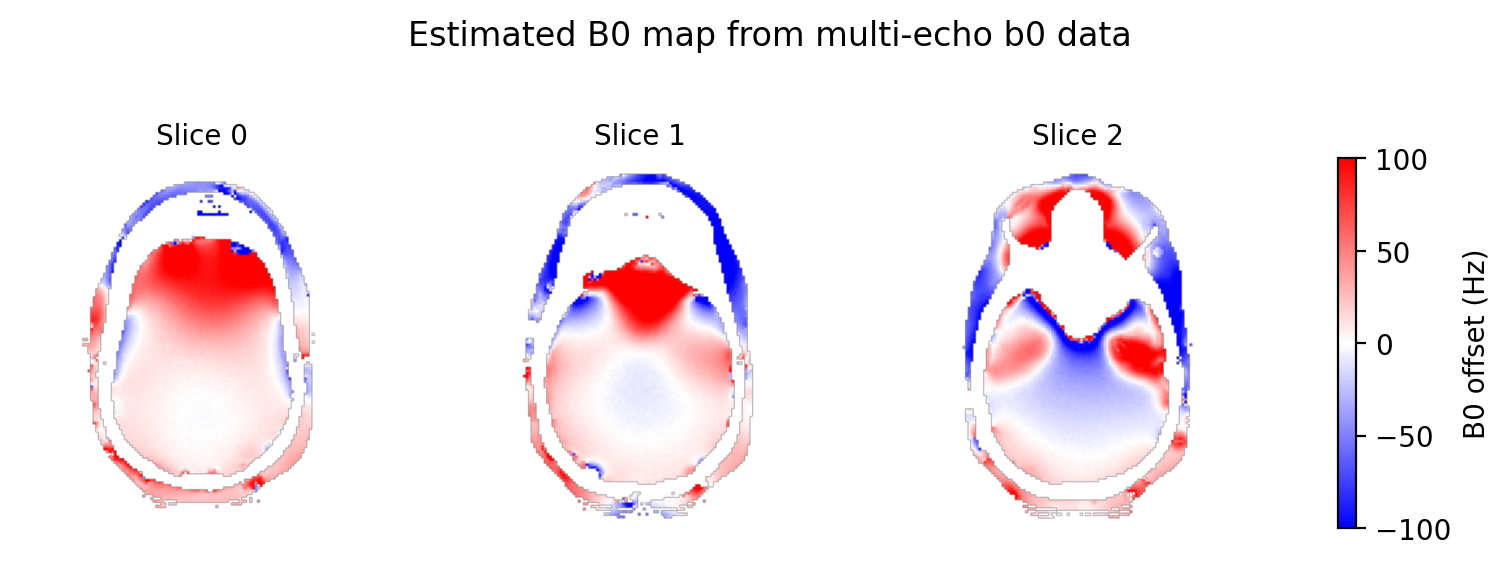

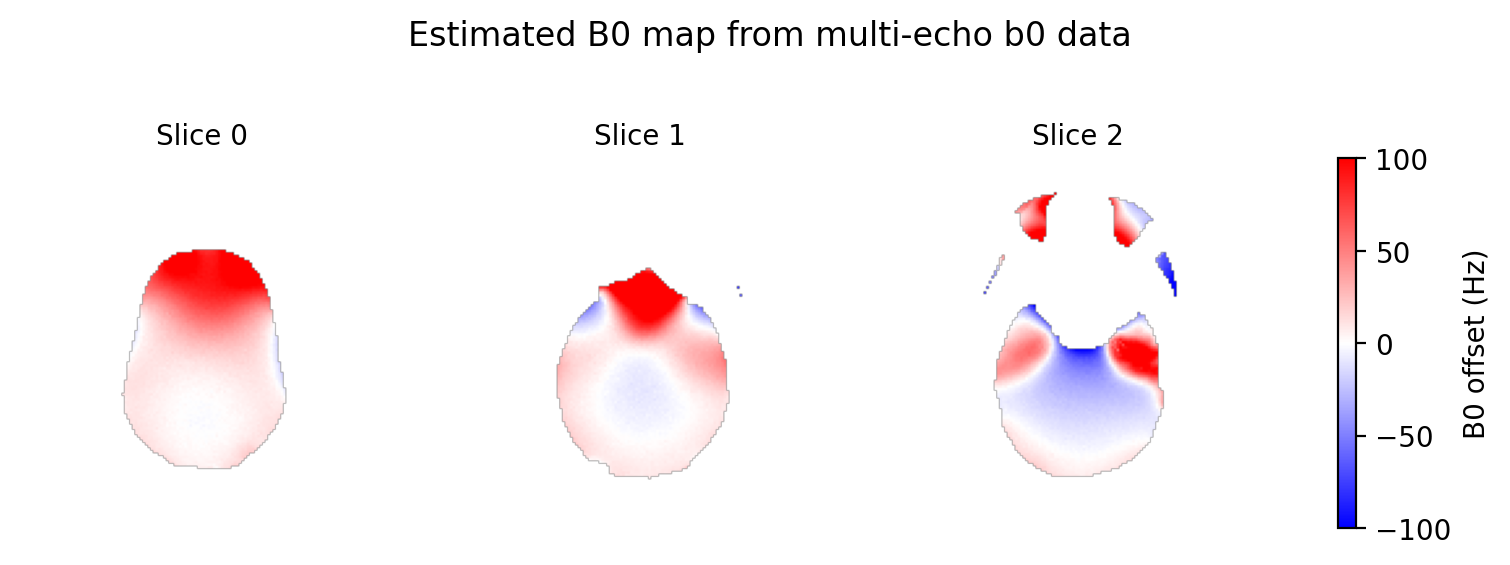

In [48]:
# ------------------------------------------------------------------
# Step 2: Coil-combine echoes and estimate B0 field map from phase evolution
# ------------------------------------------------------------------
# Coil-combine via sensitivity-weighted sum: I_comb = sum(S_c* * I_c) / sum(|S_c|^2)
sensitivity_sos = np.sum(np.abs(coil_sensitivity_maps) ** 2, axis=1) + 1e-8  # (slc, y, x)
coil_combined_numerator = np.sum(
    np.conj(coil_sensitivity_maps[:, None, ...]) * b0_coil_images, axis=2
)  # (slc, echo, y, x)
b0_coil_combined = coil_combined_numerator / sensitivity_sos[:, None, ...]
print('Coil-combined b0 image shape (slc, echo, y, x):', b0_coil_combined.shape)

from skimage.restoration import unwrap_phase

# B0 map from linear phase slope over echoes: phi(TE) = phi0 + 2*pi*df*TE
relative_phase = np.angle(b0_coil_combined * np.conj(b0_coil_combined[:, :1, :, :]))
unwrapped_phase = np.unwrap(relative_phase, axis=1)

echo_times_s = me_timing['te1'] + np.arange(n_echo_b0) * me_timing['echo_spacing']
centered_echo_times = echo_times_s - np.mean(echo_times_s)
te_variance_sum = np.sum(centered_echo_times ** 2) + 1e-12
phase_slope_rad_per_s = np.sum(
    unwrapped_phase * centered_echo_times[None, :, None, None], axis=1
) / te_variance_sum  # rad/s
b0_field_map_hz = phase_slope_rad_per_s / (2 * np.pi)

# Mask unreliable voxels (low SNR in first echo magnitude).
first_echo_magnitude = np.abs(b0_coil_combined[:, 0])
reliable_voxel_mask = first_echo_magnitude > (
    0.10 * np.max(first_echo_magnitude, axis=(-2, -1), keepdims=True)
    # 1 * np.max(first_echo_magnitude, axis=(-2, -1), keepdims=True)
)
# Erode mask to remove edge voxels with artificially high apparent B0 offsets due to noise.
from scipy.ndimage import binary_erosion
b0_field_map_masked = np.where(reliable_voxel_mask, b0_field_map_hz, np.nan)
reliable_voxel_mask_aggressive = binary_erosion(reliable_voxel_mask, iterations=2, structure=np.ones((1, 4, 4)))
b0_field_map_masked_aggressive = np.where(reliable_voxel_mask_aggressive, b0_field_map_hz, np.nan)

# Plot B0 map
fig, axes = plt.subplots(1, n_slc_b0, figsize=(10, 4), squeeze=False, dpi=200)
for s in range(n_slc_b0):
    ax = axes[0, s]
    im = ax.imshow(b0_field_map_masked[s], cmap='bwr', vmin=-100, vmax=100)
    ax.set_title(f'Slice {s}', fontsize=10)
    ax.axis('off')
fig.suptitle('Estimated B0 map from multi-echo b0 data', fontsize=12, y=0.9)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='B0 offset (Hz)')

fig, axes = plt.subplots(1, n_slc_b0, figsize=(10, 4), squeeze=False, dpi=200)
for s in range(n_slc_b0):
    ax = axes[0, s]
    im = ax.imshow(b0_field_map_masked_aggressive[s], cmap='bwr', vmin=-100, vmax=100)
    ax.set_title(f'Slice {s}', fontsize=10)
    ax.axis('off')
fig.suptitle('Estimated B0 map from multi-echo b0 data', fontsize=12, y=0.9)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='B0 offset (Hz)')

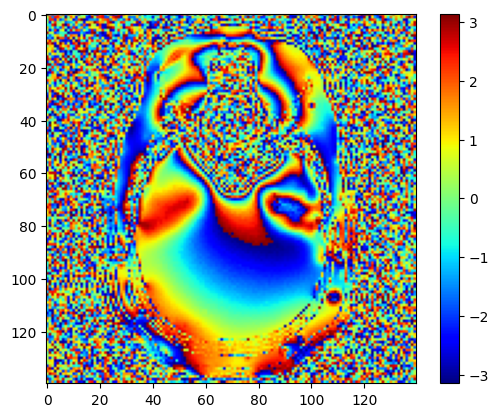

In [47]:
# plt.imshow(np.abs(b0_coil_combined[2, 0]), cmap='gray')
plt.imshow(np.angle(b0_coil_combined[2, 2]), cmap='jet')
# plt.imshow(np.angle(b0_field_map_hz[0]), cmap='bwr', vmin=-10, vmax=10)
plt.colorbar()
plt.show()

# plt.figure(figsize=(12, 6))
# for i in range(1, n_ch_b0 + 1):
#     plt.subplot(4, 8, i)
#     plt.imshow(np.angle(coil_sensitivity_maps[1, i-1]), cmap='jet')
#     plt.axis('off')
# plt.suptitle('B0 coil images (slice 1)', fontsize=12)
# plt.tight_layout()

In [19]:
# ------------------------------------------------------------------
# Step 3: Load spiral diffusion Twix and reorder to canonical shape
# ------------------------------------------------------------------
if not spiral_path.exists():
    raise FileNotFoundError(f'Could not find spiral Twix file: {spiral_path}')

spiral_twix_raw_data = read_twix(str(spiral_path), parse_pmu=False)
spiral_twix_mapped_data = map_twix(spiral_twix_raw_data)
spiral_image_object = _safe_get_twix_image_obj(spiral_twix_mapped_data)
spiral_raw_data = np.asarray(spiral_image_object[:])
print('Raw spiral image shape:', spiral_raw_data.shape)

if spiral_raw_data.ndim < 6:
    raise RuntimeError(
        f'Expected spiral data with at least 6 dims, got shape {spiral_raw_data.shape}'
    )

spiral_axis_mapping = _infer_axes_from_twix_dims(
    spiral_image_object,
    spiral_raw_data.shape,
    role_candidates={
        'rep': ('Rep',),
        'slc': ('Sli', 'Set'),
        'dir': ('Seg', 'Phs', 'Par'),
        'shot': ('Lin', 'Ave'),
        'ch': ('Cha',),
        'ro': ('Col',),
    },
    role_expected_sizes={
        'rep': int(num_repeats),
        'slc': int(n_slices),
        'dir': int(num_dirs),
        'shot': int(n_shots),
    },
)

if spiral_axis_mapping is not None:
    spiral_diffusion_data = _extract_roles_from_raw(
        spiral_raw_data,
        spiral_axis_mapping,
        ordered_roles=('rep', 'slc', 'dir', 'shot', 'ch', 'ro'),
        context_name='spiral',
    )
    print('Spiral axis map from TWIX header dims:', spiral_axis_mapping)
else:
    expected = {
        'rep': int(num_repeats),
        'slc': int(n_slices),
        'dir': int(num_dirs),
        'shot': int(n_shots),
    }
    axis_guess = _infer_axis_map_first_dims(spiral_raw_data.shape, expected)
    if len(axis_guess) != 4:
        raise RuntimeError(
            'Could not infer spiral data axes from shape. '
            'Please inspect TWIX dimensions and update mapping.'
        )

    remaining = [
        i for i in range(spiral_raw_data.ndim)
        if i not in axis_guess.values() and int(spiral_raw_data.shape[i]) > 1
    ]
    if len(remaining) < 2:
        raise RuntimeError(
            'Could not infer channel/readout axes from spiral shape. '
            f'shape={spiral_raw_data.shape}, partial_map={axis_guess}'
        )

    # Heuristic fallback: readout axis is typically the longest remaining one.
    ro_axis = max(remaining, key=lambda i: int(spiral_raw_data.shape[i]))
    ch_candidates = [i for i in remaining if i != ro_axis]
    ch_axis = min(ch_candidates, key=lambda i: int(spiral_raw_data.shape[i]))

    axis_guess['ch'] = int(ch_axis)
    axis_guess['ro'] = int(ro_axis)

    spiral_diffusion_data = _extract_roles_from_raw(
        spiral_raw_data,
        axis_guess,
        ordered_roles=('rep', 'slc', 'dir', 'shot', 'ch', 'ro'),
        context_name='spiral',
    )
    print('Spiral axis map from shape heuristic:', axis_guess)

n_rep, n_slc, n_dir, n_shot, n_ch, n_ro = spiral_diffusion_data.shape
print(
    'Canonical spiral data shape (rep, slc, dir, shot, ch, ro):',
    spiral_diffusion_data.shape,
)

if n_shot != n_shots:
    print(
        f'Warning: TWIX shot dimension ({n_shot}) != '
        f'planned n_shots ({n_shots}). Using min of both.'
    )
if n_dir != num_dirs:
    print(
        f'Warning: TWIX dir dimension ({n_dir}) != '
        f'planned num_dirs ({num_dirs}). Using min of both.'
    )

Software version: VD/VE (!?)

Scan  0


100%|██████████| 60.1M/60.1M [00:00<00:00, 1.08GB/s]


Scan  1


100%|██████████| 1.69G/1.69G [00:00<00:00, 4.04GB/s]


Raw spiral image shape: (1, 1, 1, 1, 1, 7, 1, 4, 1, 1, 1, 3, 6, 1, 32, 14008)
Spiral axis map from TWIX header dims: {'rep': 7, 'slc': 11, 'dir': 5, 'shot': 12, 'ch': 14, 'ro': 15}
Canonical spiral data shape (rep, slc, dir, shot, ch, ro): (4, 3, 7, 6, 32, 14008)


In [20]:
# ------------------------------------------------------------------
# Step 4: Build NUFFT coordinates from designed spiral interleaves
# ------------------------------------------------------------------
recon_ny = int(ny)
recon_nx = int(nx)

n_shot_use = min(int(n_shots), int(n_shot))
n_dir_use = min(int(num_dirs), int(n_dir))

trajectory_by_shot = []
for shot_idx in range(n_shot_use):
    kspace_traj_shot = np.asarray(spiral_vds.get_adc_ktraj(interleaf=shot_idx))
    if kspace_traj_shot.size == 0:
        raise RuntimeError(f'Empty trajectory for shot {shot_idx}')
    trajectory_by_shot.append(kspace_traj_shot)

# Match trajectory length with measured RO samples.
n_ro_design = min([len(k) for k in trajectory_by_shot])
n_ro_use = min(int(n_ro), int(n_ro_design))
if n_ro_use < 16:
    raise RuntimeError('Too few readout samples after matching trajectory/data lengths.')

trajectory_by_shot = [k[:n_ro_use] for k in trajectory_by_shot]

# Normalize to SigPy coordinate convention [-N/2, N/2].
kx_all = np.concatenate([np.real(k) for k in trajectory_by_shot])
ky_all = np.concatenate([np.imag(k) for k in trajectory_by_shot])
kmax_x = max(float(np.max(np.abs(kx_all))), 1e-9)
kmax_y = max(float(np.max(np.abs(ky_all))), 1e-9)

coordinates_by_shot = []
for k in trajectory_by_shot:
    coord_y = (np.imag(k) / kmax_y) * (recon_ny / 2.0)
    coord_x = (np.real(k) / kmax_x) * (recon_nx / 2.0)
    coordinates_by_shot.append(np.stack((coord_y, coord_x), axis=-1).astype(np.float32))

print('Reconstruction matrix:', (recon_ny, recon_nx))
print('Using shots:', n_shot_use, 'Using dirs:', n_dir_use)
print('RO samples used per shot:', n_ro_use)
print('Total NUFFT samples per image:', n_shot_use * n_ro_use)

Reconstruction matrix: (140, 140)
Using shots: 6 Using dirs: 7
RO samples used per shot: 14008
Total NUFFT samples per image: 84048


In [21]:
# ------------------------------------------------------------------
# Step 5: Direct SigPy NUFFT-SENSE reconstruction
# ------------------------------------------------------------------
spiral_sense_recon_images = np.zeros(
    (n_rep, n_slc, n_dir_use, recon_ny, recon_nx), dtype=np.complex64
)

# Ensure sensitivity map resolution matches target reconstruction matrix.
sensitivity_maps_aligned = np.asarray(coil_sensitivity_maps, dtype=np.complex64)
if sensitivity_maps_aligned.shape[-2:] != (recon_ny, recon_nx):
    sensitivity_maps_aligned = _center_crop_or_pad_2d(
        sensitivity_maps_aligned, recon_ny, recon_nx
    )

if sensitivity_maps_aligned.shape[0] != n_slc:
    raise RuntimeError(
        f'Slice mismatch: sensitivities ({sensitivity_maps_aligned.shape[0]}) '
        f'vs spiral data ({n_slc}).'
    )
if sensitivity_maps_aligned.shape[1] != n_ch:
    raise RuntimeError(
        f'Channel mismatch: sensitivities ({sensitivity_maps_aligned.shape[1]}) '
        f'vs spiral data ({n_ch}).'
    )

total_items = n_rep * n_slc * n_dir_use
print('Starting NUFFT reconstruction ...')
with tqdm(total=total_items, desc='Spiral NUFFT Recon', leave=False) as pbar:
    for rep_idx in range(n_rep):
        for slc_idx in range(n_slc):
            sensitivity_maps_gpu = sp.to_device(
                sensitivity_maps_aligned[slc_idx], _sp_device
            )

            for dir_idx in range(n_dir_use):
                # Extract single (rep, slc, dir) frame: (shot, ch, ro)
                single_frame_data = np.asarray(
                    spiral_diffusion_data[
                        rep_idx, slc_idx, dir_idx, :n_shot_use, :, :n_ro_use
                    ],
                    dtype=np.complex64,
                )

                # Concatenate all shots into one non-Cartesian acquisition.
                concatenated_kspace = np.concatenate(
                    [single_frame_data[s] for s in range(n_shot_use)], axis=-1
                )  # (ch, total_pts)
                concatenated_coords = np.concatenate(
                    [coordinates_by_shot[s] for s in range(n_shot_use)], axis=0
                )  # (total_pts, 2)

                kspace_gpu = sp.to_device(concatenated_kspace, _sp_device)
                coords_gpu = sp.to_device(concatenated_coords, _sp_device)

                density_compensation_gpu = sp.mri.dcf.pipe_menon_dcf(
                    coords_gpu,
                    img_shape=(recon_ny, recon_nx),
                    max_iter=15,
                    show_pbar=False,
                    device=_sp_device,
                )

                sense_reconstruction = sp.mri.app.SenseRecon(
                    y=kspace_gpu,
                    mps=sensitivity_maps_gpu,
                    coord=coords_gpu,
                    weights=density_compensation_gpu,
                    max_iter=50,
                    lamda=1e-3,
                    solver="PrimalDualHybridGradient",
                    device=_sp_device,
                    show_pbar=False,
                )

                reconstructed_image_gpu = sense_reconstruction.run()
                spiral_sense_recon_images[rep_idx, slc_idx, dir_idx] = np.asarray(
                    sp.to_device(reconstructed_image_gpu, sp.Device(-1)),
                    dtype=np.complex64,
                )
                pbar.update(1)

print('Reconstruction done. Image shape:', spiral_sense_recon_images.shape)

Starting NUFFT reconstruction ...


Spiral NUFFT Recon:   0%|          | 0/84 [00:00<?, ?it/s]

Reconstruction done. Image shape: (4, 3, 7, 140, 140)


In [22]:
# ------------------------------------------------------------------
# Step 6: Interactive visualization (rep/slice/dwi, optimized)
# ------------------------------------------------------------------
import io
import ipywidgets as widgets
from IPython.display import display
from PIL import Image

img_vis = np.asarray(spiral_sense_recon_images)  # (rep, slc, dir, y, x)
if img_vis.ndim != 5:
    raise RuntimeError(
        f"Expected spiral_sense_recon_images with 5 dims (rep, slc, dir, y, x), "
        f"got {img_vis.shape}"
    )

n_rep_vis, n_slc_vis, n_dir_vis = img_vis.shape[:3]

# Precompute display orientation once to avoid repeated transposes while sliding.
img_vis_disp = np.transpose(img_vis, (0, 1, 2, 4, 3))  # (rep, slc, dir, x, y)
mag_vis = np.abs(img_vis_disp).astype(np.float32, copy=False)
phs_vis = np.angle(img_vis_disp).astype(np.float32, copy=False)

# Use one global magnitude scale to prevent brightness pumping.
mag_vmax = float(np.percentile(mag_vis, 99.5))
if not np.isfinite(mag_vmax) or mag_vmax <= 0:
    mag_vmax = 1.0

rep_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, n_rep_vis - 1),
    step=1,
    description='show_rep',
    continuous_update=True,
    readout=True,
    style={'description_width': 'initial'},
)

slc_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, n_slc_vis - 1),
    step=1,
    description='show_slc',
    continuous_update=True,
    readout=True,
    style={'description_width': 'initial'},
)

dwi_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, n_dir_vis - 1),
    step=1,
    description='show_dwi',
    continuous_update=True,
    readout=True,
    style={'description_width': 'initial'},
)

ui = widgets.HBox([rep_slider, slc_slider, dwi_slider])


def _array_to_png_bytes(arr, vmin, vmax, cmap):
    arr = np.asarray(arr, dtype=np.float32)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmin, vmax = 0.0, 1.0
    norm = np.clip((arr - vmin) / (vmax - vmin), 0.0, 1.0)
    rgba = (cmap(norm) * 255).astype(np.uint8)
    img = Image.fromarray(rgba, mode='RGBA')
    buf = io.BytesIO()
    img.save(buf, format='PNG', optimize=False, compress_level=1)
    return buf.getvalue()


# Pre-render all frames once so slider updates only swap PNG buffers.
print('Pre-rendering display frames for smooth interaction ...')
gray_cmap = plt.get_cmap('gray')
jet_cmap = plt.get_cmap('jet')

mag_png = np.empty((n_rep_vis, n_slc_vis, n_dir_vis), dtype=object)
phs_png = np.empty((n_rep_vis, n_slc_vis, n_dir_vis), dtype=object)

for rep_idx in range(n_rep_vis):
    for slc_idx in range(n_slc_vis):
        for dir_idx in range(n_dir_vis):
            frame_vmax = float(np.percentile(mag_vis[rep_idx, slc_idx, dir_idx], 99.5))
            mag_png[rep_idx, slc_idx, dir_idx] = _array_to_png_bytes(
                mag_vis[rep_idx, slc_idx, dir_idx].T,
                0.0,
                frame_vmax,
                gray_cmap,
            )
            phs_png[rep_idx, slc_idx, dir_idx] = _array_to_png_bytes(
                phs_vis[rep_idx, slc_idx, dir_idx].T,
                -np.pi,
                np.pi,
                jet_cmap,
            )

print('Pre-render complete.')

title_mag = widgets.HTML()
title_phs = widgets.HTML()
mag_widget = widgets.Image(format='png', layout=widgets.Layout(width='500px', height='500px'))
phs_widget = widgets.Image(format='png', layout=widgets.Layout(width='500px', height='500px'))

view = widgets.HBox([
    widgets.VBox([title_mag, mag_widget]),
    widgets.VBox([title_phs, phs_widget]),
])


def _update_widget_images(_=None):
    show_rep = int(rep_slider.value)
    show_slc = int(slc_slider.value)
    show_dwi = int(dwi_slider.value)

    mag_widget.value = mag_png[show_rep, show_slc, show_dwi]
    phs_widget.value = phs_png[show_rep, show_slc, show_dwi]

    title_mag.value = (
        f'<b>Rep {show_rep} | Slice {show_slc} | '
        f'{dir_labels[show_dwi]} | Magnitude</b>'
    )
    title_phs.value = (
        f'<b>Rep {show_rep} | Slice {show_slc} | '
        f'{dir_labels[show_dwi]} | Phase</b>'
    )


rep_slider.observe(_update_widget_images, names='value')
slc_slider.observe(_update_widget_images, names='value')
dwi_slider.observe(_update_widget_images, names='value')
_update_widget_images()

display(widgets.VBox([ui, view]))
print('Interactive mode: rep/slice/dwi sliders with pre-rendered images for low-lag browsing.')

Pre-rendering display frames for smooth interaction ...
Pre-render complete.


Interactive mode: rep/slice/dwi sliders with pre-rendered images for low-lag browsing.


In [23]:
class SpiralOffresExactLinop(sp.linop.Linop):
    def __init__(
        self,
        img_shape,
        sens,
        coord,
        field_map_hz,
        sample_time_s,
        device,
        weights_sqrt=None,
        time_batch_size=1024,
    ):
        """
        Exact phase-accumulation MRI operator (no NUFFT segmentation).

        Forward model:
            y_c(t) = sum_r s_c(r) * x(r) * exp(-i * phi(r,t))
            phi(r,t) = 2*pi*df(r)*t + 2*pi*(ky(t)*ry/ny + kx(t)*rx/nx)

        where df is in Hz (so 2*pi*df = gamma*DeltaB0 in rad/s).
        """
        self.device = sp.Device(device)
        self.ny, self.nx = [int(v) for v in img_shape]

        sens = np.asarray(sens, dtype=np.complex64)
        if sens.shape[-2:] != (self.ny, self.nx):
            raise ValueError(f"sens shape mismatch: {sens.shape[-2:]} vs {(self.ny, self.nx)}")

        self.nc = int(sens.shape[0])
        self.npix = int(self.ny * self.nx)

        coord = np.asarray(coord, dtype=np.float32)
        if coord.ndim != 2 or coord.shape[1] != 2:
            raise ValueError(f"coord must be (ns, 2), got {coord.shape}")
        self.ns = int(coord.shape[0])

        t = np.asarray(sample_time_s, dtype=np.float32).reshape(-1)
        if t.shape[0] != self.ns:
            raise ValueError(
                f"sample_time_s length mismatch: {t.shape[0]} vs ns={self.ns}"
            )

        fmap = np.asarray(field_map_hz, dtype=np.float32)
        if fmap.shape != (self.ny, self.nx):
            raise ValueError(
                f"field_map_hz shape mismatch: got {fmap.shape}, expected {(self.ny, self.nx)}"
            )

        self.time_batch_size = max(64, int(time_batch_size))

        self.sens = sp.to_device(sens.reshape(self.nc, self.npix), self.device)
        self.coord = sp.to_device(coord, self.device)
        self.field_map_hz = sp.to_device(fmap.reshape(self.npix), self.device)
        self.time_s = sp.to_device(t, self.device)

        # Spatial index grid centered at k-space origin.
        ry = (np.arange(self.ny, dtype=np.float32) - self.ny / 2.0) / float(self.ny)
        rx = (np.arange(self.nx, dtype=np.float32) - self.nx / 2.0) / float(self.nx)
        gy, gx = np.meshgrid(ry, rx, indexing="ij")
        self.ry = sp.to_device(gy.reshape(self.npix), self.device)
        self.rx = sp.to_device(gx.reshape(self.npix), self.device)

        if weights_sqrt is None:
            self.weights_sqrt = None
        else:
            ws = np.asarray(weights_sqrt, dtype=np.float32).reshape(-1)
            if ws.shape[0] != self.ns:
                raise ValueError(
                    f"weights_sqrt length mismatch: {ws.shape[0]} vs ns={self.ns}"
                )
            self.weights_sqrt = sp.to_device(ws, self.device)

        super().__init__((self.nc, self.ns), (self.ny, self.nx))

    def _phase_block(self, coord_b, time_b):
        xp = self.device.xp

        phi_offres = 2.0 * xp.pi * xp.outer(time_b, self.field_map_hz)
        ky = coord_b[:, 0]
        kx = coord_b[:, 1]
        phi_grad = 2.0 * xp.pi * (
            xp.outer(ky, self.ry) + xp.outer(kx, self.rx)
        )
        return (-phi_offres + phi_grad).astype(xp.float32, copy=False)

    def _apply(self, x):
        xp = self.device.xp
        x = sp.to_device(x, self.device).reshape(self.npix).astype(xp.complex64, copy=False)

        y = xp.zeros((self.nc, self.ns), dtype=xp.complex64)

        for t_start in range(0, self.ns, self.time_batch_size):
            t_end = min(t_start + self.time_batch_size, self.ns)

            coord_b = self.coord[t_start:t_end]
            time_b = self.time_s[t_start:t_end]
            phase = self._phase_block(coord_b, time_b)
            E = xp.exp(-1j * phase).astype(xp.complex64, copy=False)

            for c in range(self.nc):
                y[c, t_start:t_end] = E @ (self.sens[c] * x)

        if self.weights_sqrt is not None:
            y = y * self.weights_sqrt[None, :]

        return y

    def _adjoint_linop(self):
        return SpiralOffresExactAdjointLinop(self)


class SpiralOffresExactAdjointLinop(sp.linop.Linop):
    def __init__(self, parent):
        self.parent = parent
        super().__init__(parent.ishape, parent.oshape)

    def _apply(self, y):
        p = self.parent
        xp = p.device.xp
        y = sp.to_device(y, p.device).astype(xp.complex64, copy=False)

        if p.weights_sqrt is not None:
            y = y * p.weights_sqrt[None, :]

        x_acc = xp.zeros(p.npix, dtype=xp.complex64)

        for t_start in range(0, p.ns, p.time_batch_size):
            t_end = min(t_start + p.time_batch_size, p.ns)

            coord_b = p.coord[t_start:t_end]
            time_b = p.time_s[t_start:t_end]
            phase = p._phase_block(coord_b, time_b)
            E_adj = xp.exp(1j * phase).astype(xp.complex64, copy=False)

            for c in range(p.nc):
                x_acc += xp.conj(p.sens[c]) * (E_adj.T @ y[c, t_start:t_end])

        return x_acc.reshape(p.ny, p.nx)

    def _adjoint_linop(self):
        return self.parent


class SpiralOffresExactRecon(sp.app.LinearLeastSquares):
    def __init__(
        self,
        y,
        sens,
        coord,
        field_map_hz,
        sample_time_s,
        lamda=0,
        device=sp.cpu_device,
        weights_sqrt=None,
        time_batch_size=1024,
        show_pbar=True,
        **kwargs,
    ):
        device = sp.Device(device)
        y = sp.to_device(np.asarray(y, dtype=np.complex64), device=device)

        A = SpiralOffresExactLinop(
            img_shape=sens.shape[1:],
            sens=sens,
            coord=coord,
            field_map_hz=field_map_hz,
            sample_time_s=sample_time_s,
            device=device,
            weights_sqrt=weights_sqrt,
            time_batch_size=time_batch_size,
        )

        super().__init__(A, y, lamda=lamda, show_pbar=show_pbar, **kwargs)

In [127]:
# ------------------------------------------------------------------
# Step 4b: Exact off-resonance reconstruction (direct phase accumulation)
# ------------------------------------------------------------------
#
# REFACTORING RECOMMENDATION: 
# The following components can be wrapped into an external function/class (e.g. `recon_utils.py`):
#   - `_prepare_field_map_slice`, `_sharpness_metric`, `_contrast_metric`, `_safe_norm_ratio`
#   - The lambda sweep search block and metrics computation could be encapsulated into an `optimize_offres_recon()` wrapper.
#
from scipy.ndimage import gaussian_filter

required = [
    "spiral_diffusion_data", "sensitivity_maps_aligned", "coordinates_by_shot",
    "n_shot_use", "n_ro_use", "adc_dwell_s", "recon_ny", "recon_nx",
    "_sp_device", "b0_field_map_masked", "spiral_sense_recon_images",
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")


def _prepare_field_map_slice(field_map_all, slc_idx, ny, nx, smooth_sigma=1.0):
    """Extract and clean up a single-slice B0 field map for off-resonance correction."""
    fmap = np.asarray(field_map_all[int(slc_idx)], dtype=np.float32)
    if fmap.shape != (int(ny), int(nx)):
        if "_center_crop_or_pad_2d" not in globals():
            raise RuntimeError(
                f"Field-map shape mismatch: {fmap.shape} vs {(int(ny), int(nx))}"
            )
        fmap = _center_crop_or_pad_2d(fmap[None, ...], int(ny), int(nx))[0].astype(np.float32)

    finite = np.isfinite(fmap)
    if not np.any(finite):
        return np.zeros((int(ny), int(nx)), dtype=np.float32)

    fill = float(np.nanmedian(fmap[finite]))
    fmap = np.where(finite, fmap, fill).astype(np.float32)

    if float(smooth_sigma) > 0:
        fmap = gaussian_filter(fmap, sigma=float(smooth_sigma)).astype(np.float32)

    fmap -= float(np.median(fmap))
    return fmap


def _sharpness_metric(img):
    """Mean gradient magnitude — higher = sharper."""
    mag = np.abs(np.asarray(img, dtype=np.complex64)).astype(np.float32)
    gx, gy = np.gradient(mag)
    return float(np.mean(np.sqrt(gx * gx + gy * gy)))


def _contrast_metric(img):
    """90th–10th percentile range — higher = more contrast."""
    mag = np.abs(np.asarray(img, dtype=np.complex64)).astype(np.float32)
    return float(np.percentile(mag, 90) - np.percentile(mag, 10))


def _safe_norm_ratio(num, den, eps=1e-20):
    """Safe division for norm ratios, avoids division by zero."""
    return float(num) / max(float(den), float(eps))


# Select slice and direction representation. Average across all repetitions (axis 0).
# offres_rep = 3
offres_slc = 1
offres_dir = 5

nominal_coordinates = np.concatenate(
    [
        np.asarray(coordinates_by_shot[s][: int(n_ro_use)], dtype=np.float32)
        for s in range(int(n_shot_use))
    ],
    axis=0,
).astype(np.float32)

# Instead of fetching a single frame, we take the average over the repeated scans (axis 0)
single_frame_data = np.asarray(
    np.mean(
        spiral_diffusion_data[
            :, offres_slc, offres_dir, : int(n_shot_use), :, : int(n_ro_use)
        ],
        axis=0
    ),
    dtype=np.complex64,
)
concatenated_kspace = np.concatenate(
    [single_frame_data[s] for s in range(int(n_shot_use))], axis=-1
).astype(np.complex64)

sample_time_s = np.tile(
    np.arange(int(n_ro_use), dtype=np.float32) * float(adc_dwell_s),
    int(n_shot_use),
).astype(np.float32)

if sample_time_s.shape[0] != nominal_coordinates.shape[0]:
    n = min(sample_time_s.shape[0], nominal_coordinates.shape[0])
    sample_time_s = sample_time_s[:n]
    nominal_coordinates = nominal_coordinates[:n]
    concatenated_kspace = concatenated_kspace[:, :n]

field_map_hz = _prepare_field_map_slice(
    # b0_field_map_masked,
    b0_field_map_hz,
    slc_idx=offres_slc,
    ny=int(recon_ny),
    nx=int(recon_nx),
    smooth_sigma=float(globals().get("offres_fmap_smooth_sigma", 1.0)),
)

slice_sensitivity_maps = np.asarray(
    sensitivity_maps_aligned[offres_slc], dtype=np.complex64
)
if slice_sensitivity_maps.shape[-2:] != (int(recon_ny), int(recon_nx)):
    slice_sensitivity_maps = _center_crop_or_pad_2d(
        slice_sensitivity_maps, int(recon_ny), int(recon_nx)
    ).astype(np.complex64)

# Density compensation: used as sqrt(W) in weighted least squares.
coords_gpu = sp.to_device(nominal_coordinates, _sp_device)
density_compensation_gpu = sp.mri.dcf.pipe_menon_dcf(
    coords_gpu,
    img_shape=(int(recon_ny), int(recon_nx)),
    max_iter=15,
    show_pbar=False,
    device=_sp_device,
)
density_compensation = np.asarray(
    sp.to_device(density_compensation_gpu, sp.Device(-1)), dtype=np.float32
)
sqrt_density_weights = np.sqrt(np.maximum(density_compensation, 1e-8)).astype(np.float32)
weighted_kspace = (concatenated_kspace * sqrt_density_weights[None, :]).astype(np.complex64)

# --- Nominal (no off-resonance) reconstruction baseline ---
baseline_recon = sp.mri.app.SenseRecon(
# baseline_recon = sp.mri.app.TotalVariationRecon(
    y=sp.to_device(concatenated_kspace, _sp_device),
    mps=sp.to_device(slice_sensitivity_maps, _sp_device),
    coord=coords_gpu,
    weights=sp.to_device(density_compensation, _sp_device),
    max_iter=35,
    lamda=1e-3,
    solver="PrimalDualHybridGradient",
    device=_sp_device,
    show_pbar=True,
)
nominal_recon_image = np.asarray(
    sp.to_device(baseline_recon.run(), sp.Device(-1)), dtype=np.complex64
)

nominal_sharpness = _sharpness_metric(nominal_recon_image)
nominal_contrast = _contrast_metric(nominal_recon_image)

# --- Exact off-resonance model sweep ---
lambda_grid = [1e-7]
max_iter_exact = 10
offres_results = []

for lambda_val in lambda_grid:
    offres_exact_recon = SpiralOffresExactRecon(
        y=weighted_kspace,
        sens=slice_sensitivity_maps,
        coord=nominal_coordinates,
        field_map_hz=field_map_hz,
        sample_time_s=sample_time_s,
        lamda=float(lambda_val),
        device=_sp_device,
        weights_sqrt=sqrt_density_weights,
        time_batch_size=int(globals().get("offres_time_batch_size", 4096)),
        solver="ConjugateGradient",
        max_iter=max_iter_exact,
        tol=1e-11,
        show_pbar=True,
        x=sp.to_device(nominal_recon_image, _sp_device),
    )

    image_gpu = offres_exact_recon.run()
    reconstructed_image = np.asarray(
        sp.to_device(image_gpu, sp.Device(-1)), dtype=np.complex64
    )
    forward_result = np.asarray(
        sp.to_device(offres_exact_recon.A * image_gpu, sp.Device(-1)),
        dtype=np.complex64,
    )

    relative_residual = _safe_norm_ratio(
        np.linalg.norm((forward_result - weighted_kspace).ravel()),
        np.linalg.norm(weighted_kspace.ravel()),
    )
    sharp = _sharpness_metric(reconstructed_image)
    contrast = _contrast_metric(reconstructed_image)
    score = (
        (sharp / max(nominal_sharpness, 1e-20))
        + 0.30 * (contrast / max(nominal_contrast, 1e-20))
        - 0.45 * relative_residual
    )

    offres_results.append(
        {
            "lambda": float(lambda_val),
            "img": reconstructed_image,
            "residual": float(relative_residual),
            "sharpness": float(sharp),
            "contrast": float(contrast),
            "score": float(score),
        }
    )

offres_results.sort(key=lambda r: r["score"], reverse=True)
best_result = offres_results[0]

# Conservative acceptance: keep exact model only when it materially improves sharpness.
if best_result["sharpness"] >= 1.02 * nominal_sharpness:
    offres_corrected_case = np.asarray(best_result["img"], dtype=np.complex64)
    final_tag = "exact off-res accepted"
else:
    offres_corrected_case = np.asarray(nominal_recon_image, dtype=np.complex64)
    final_tag = "fallback to nominal"

if "img_sense_spiral_offres" not in globals():
    img_sense_spiral_offres = np.asarray(
        spiral_sense_recon_images, dtype=np.complex64
    ).copy()
img_sense_spiral_offres[offres_rep, offres_slc, offres_dir] = offres_corrected_case

print(
    "Field-map stats [Hz]:",
    float(np.min(field_map_hz)),
    float(np.max(field_map_hz)),
    float(np.std(field_map_hz)),
)
print("Decision:", final_tag)
print(
    f"Nominal sharpness/contrast: {nominal_sharpness:.4e} / {nominal_contrast:.4e}"
)
print(
    f"Best exact sharpness/contrast/residual: {best_result['sharpness']:.4e} / "
    f"{best_result['contrast']:.4e} / {best_result['residual']:.4e} "
    f"(lambda={best_result['lambda']:.1e})"
)

magnitude_nominal = np.abs(nominal_recon_image).astype(np.float32)
magnitude_offres = np.abs(best_result["img"]).astype(np.float32)
magnitude_final = np.abs(offres_corrected_case).astype(np.float32)

phase_nominal = np.angle(nominal_recon_image).astype(np.float32)
phase_offres = np.angle(best_result["img"]).astype(np.float32)

display_vmax = float(
    max(
        np.percentile(magnitude_nominal, 99.5),
        np.percentile(magnitude_offres, 99.5),
        1e-12,
    )
)
magnitude_difference = magnitude_final - magnitude_nominal
diff_display_max = float(np.percentile(np.abs(magnitude_difference), 99.5))
diff_display_max = (
    diff_display_max if np.isfinite(diff_display_max) and diff_display_max > 0 else 1.0
)

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

SenseRecon:   0%|          | 0/35 [00:00<?, ?it/s]

SpiralOffresExactRecon:   0%|          | 0/10 [00:00<?, ?it/s]

Field-map stats [Hz]: -145.71034240722656 178.1690216064453 37.74577331542969
Decision: exact off-res accepted
Nominal sharpness/contrast: 2.1788e-15 / 1.5148e-14
Best exact sharpness/contrast/residual: 9.5015e-09 / 6.6821e-08 / 6.2935e-01 (lambda=1.0e-07)


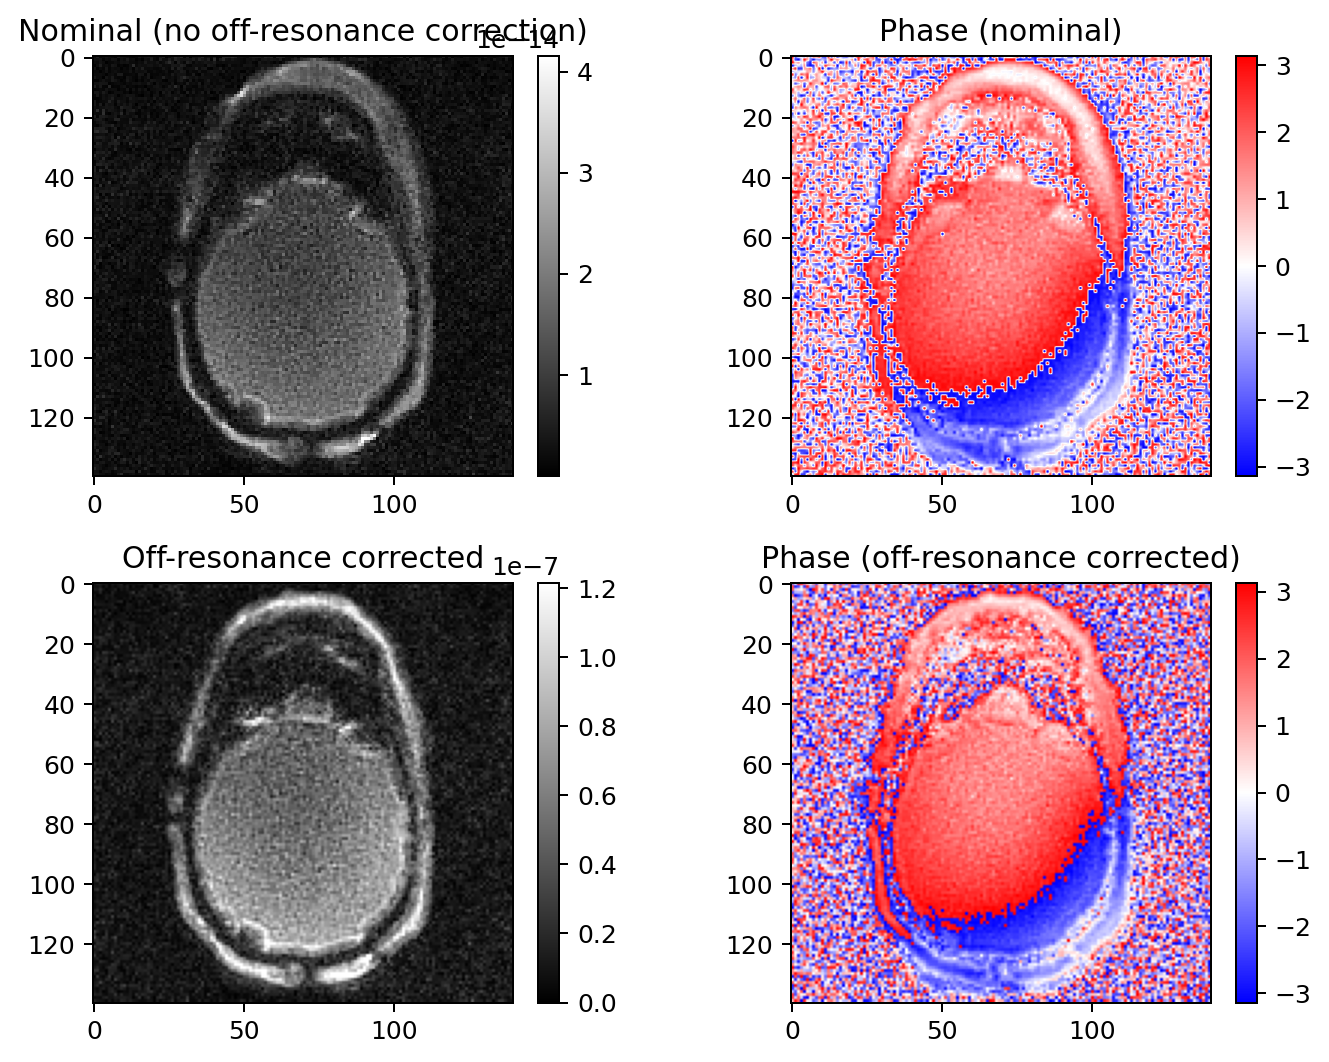

Exact-model candidates:
  01. lambda=1.0e-07, score=5684323.3032, sharpness=9.5015e-09, contrast=6.6821e-08, residual=6.2935e-01


In [129]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6), dpi=180)
im0 = ax[0, 0].imshow(magnitude_nominal, cmap="gray")
ax[0, 0].set_title("Nominal (no off-resonance correction)")
plt.colorbar(im0, ax=ax[0, 0], fraction=0.046, pad=0.04)

im1 = ax[1, 0].imshow(magnitude_offres, cmap="gray", vmin=0, vmax=display_vmax)
ax[1, 0].set_title("Off-resonance corrected")
plt.colorbar(im1, ax=ax[1, 0], fraction=0.046, pad=0.04)

im2 = ax[0, 1].imshow(phase_nominal, cmap="bwr", vmin=-np.pi, vmax=np.pi)
ax[0, 1].set_title("Phase (nominal)")
plt.colorbar(im2, ax=ax[0, 1], fraction=0.046, pad=0.04)

im3 = ax[1, 1].imshow(phase_offres, cmap="bwr", vmin=-np.pi, vmax=np.pi)
ax[1, 1].set_title("Phase (off-resonance corrected)")
plt.colorbar(im3, ax=ax[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Exact-model candidates:")
for i, r in enumerate(offres_results):
    print(
        f"  {i+1:02d}. lambda={r['lambda']:.1e}, score={r['score']:.4f}, "
        f"sharpness={r['sharpness']:.4e}, contrast={r['contrast']:.4e}, "
        f"residual={r['residual']:.4e}"
    )

In [26]:
# ------------------------------------------------------------------
# Load ACDC fieldmap data (Bay 5 calibration)
# ------------------------------------------------------------------
ACDC_fieldmap_data = np.load('ACDC_fieldmap_data/fieldmap_bay5.npz')
ACDC_fieldmap = ACDC_fieldmap_data['fieldmap_Hz']       # basis fieldmaps
fieldmap_coords = ACDC_fieldmap_data['coords_xyz']       # spatial coordinate grid
fieldmap_mask = ACDC_fieldmap_data['data_mask']          # valid-data mask
print(
    'Loaded ACDC fieldmap data with shapes:',
    ACDC_fieldmap.shape, fieldmap_coords.shape, fieldmap_mask.shape,
)

Loaded ACDC fieldmap data with shapes: (31, 112, 112, 112) (3, 112, 112, 112) (112, 112, 112)


Extracted center slice fieldmap values, shape: (31, 13753)


  0%|          | 0/31 [00:00<?, ?it/s]

C:\Users\bughh\AppData\Local\Temp\ipykernel_39280\918940246.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


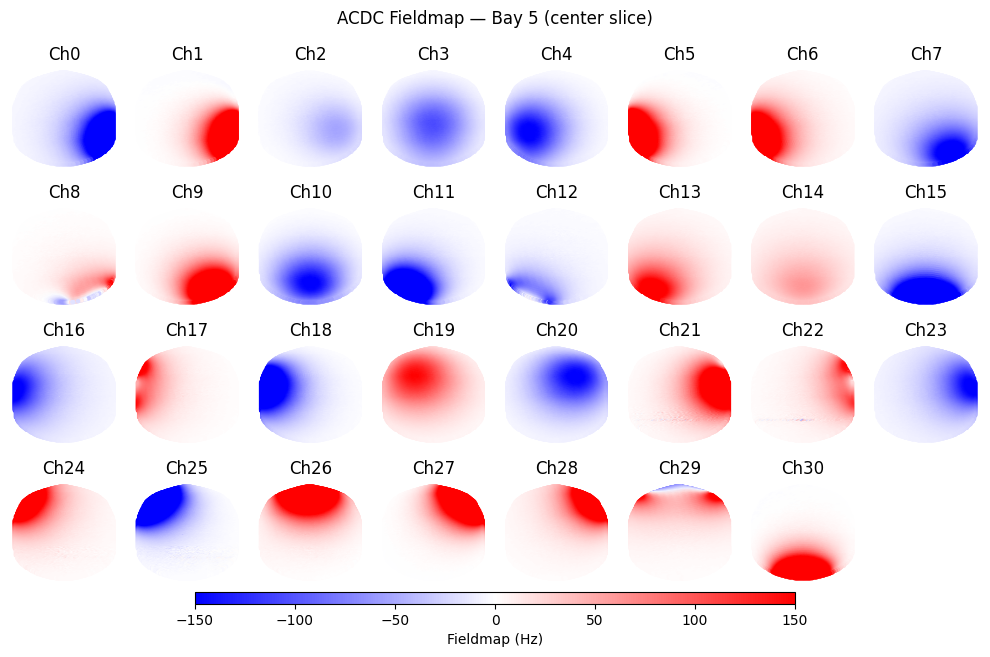

In [27]:
# ------------------------------------------------------------------
# Visualize ACDC fieldmap: center-slice basis maps
# ------------------------------------------------------------------
center_slice_indices = np.logical_and(
    fieldmap_mask != 0,
    np.abs(fieldmap_coords[2] - 0) <= slice_thickness * 1e3 / 2,
)
ACDC_fieldmap_center_slice = ACDC_fieldmap[..., center_slice_indices]
print('Extracted center slice fieldmap values, shape:', ACDC_fieldmap_center_slice.shape)

plt.figure(figsize=(10, 6))
for i in tqdm(range(31)):
    plt.subplot(4, 8, i + 1)
    plt.scatter(
        fieldmap_coords[0][center_slice_indices],
        fieldmap_coords[1][center_slice_indices],
        c=ACDC_fieldmap_center_slice[i],
        cmap='bwr', vmin=-150, vmax=150, s=5,
    )
    plt.xticks([])
    plt.yticks([])
    plt.title(f"Ch{i}")
    plt.axis('off')

cbar_ax = plt.gcf().add_axes([0.2, -0.01, 0.6, 0.02])
plt.colorbar(cax=cbar_ax, orientation='horizontal', label='Fieldmap (Hz)')
plt.suptitle("ACDC Fieldmap — Bay 5 (center slice)")
plt.tight_layout()

In [28]:
# ------------------------------------------------------------------
# Quick inspection of ACDC fieldmap coordinate system
# ------------------------------------------------------------------
print('Fieldmap coords shape:', fieldmap_coords.shape)
print('Fieldmap coords axis ranges:')
for axis_idx, axis_name in enumerate(['x', 'y', 'z']):
    axis_vals = fieldmap_coords[axis_idx]
    print(f'  {axis_name}: [{axis_vals.min():.2f}, {axis_vals.max():.2f}] (mm)')

print(f'\nFieldmap mask: {fieldmap_mask.shape}, non-zero: {np.count_nonzero(fieldmap_mask)}')
print(f'ACDC fieldmap shape: {ACDC_fieldmap.shape} ({ACDC_fieldmap.shape[0]} channels)')

# Imaging coordinate system (same as b0 / spiral)
print(f'\nImaging parameters:')
print(f'  FOV: {fov*1e3:.0f} mm')
print(f'  Matrix: {nx}x{ny}')
print(f'  Voxel size: {fov/nx*1e3:.2f} mm')
print(f'  Slices: {n_slices}')
print(f'  Slice thickness: {slice_thickness*1e3:.1f} mm')
print(f'  Slice gap: {slice_gap*1e3:.1f} mm')
print(f'  Slice offsets (mm): {slice_offsets*1e3}')

# Imaging pixel coordinates in mm
x_mm = (np.arange(nx, dtype=np.float32) - (nx - 1) / 2.0) * (fov / nx) * 1e3
y_mm = (np.arange(ny, dtype=np.float32) - (ny - 1) / 2.0) * (fov / ny) * 1e3
print(f'  X range: [{x_mm[0]:.2f}, {x_mm[-1]:.2f}] mm')
print(f'  Y range: [{y_mm[0]:.2f}, {y_mm[-1]:.2f}] mm')

Fieldmap coords shape: (3, 112, 112, 112)
Fieldmap coords axis ranges:
  x: [-112.00, 110.00] (mm)
  y: [-110.00, 112.00] (mm)
  z: [-91.00, 131.00] (mm)

Fieldmap mask: (112, 112, 112), non-zero: 528610
ACDC fieldmap shape: (31, 112, 112, 112) (31 channels)

Imaging parameters:
  FOV: 210 mm
  Matrix: 140x140
  Voxel size: 1.50 mm
  Slices: 3
  Slice thickness: 5.0 mm
  Slice gap: 10.0 mm
  Slice offsets (mm): [-15.   0.  15.]
  X range: [-104.25, 104.25] mm
  Y range: [-104.25, 104.25] mm


In [29]:
# ======================================================================
# ACDC Shim Optimization: Slice-by-slice quadratic programming
# ======================================================================
# Interpolate the ACDC fieldmap basis onto each imaging slice,
# then solve min ||W*x - b0||^2 subject to |x_i| < 3A, sum|x_i| < 35A.
# ======================================================================
from scipy.interpolate import RegularGridInterpolator
import quadprog
from tqdm.auto import tqdm

# ---- Step 1: Build ACDC basis interpolators ----
acdc_x = np.sort(np.unique(np.round(fieldmap_coords[0].ravel(), 1))).astype(np.float64)
acdc_y = np.sort(np.unique(np.round(fieldmap_coords[1].ravel(), 1))).astype(np.float64)
acdc_z = np.sort(np.unique(np.round(fieldmap_coords[2].ravel(), 1))).astype(np.float64)
print(f'ACDC grid: X={len(acdc_x)}, Y={len(acdc_y)}, Z={len(acdc_z)}')
assert len(acdc_x) == ACDC_fieldmap.shape[1]
assert len(acdc_y) == ACDC_fieldmap.shape[2]
assert len(acdc_z) == ACDC_fieldmap.shape[3]

n_acdc_channels = ACDC_fieldmap.shape[0]  # 31
acdc_interpolators = []
for ch_idx in range(n_acdc_channels):
    basis_vol = np.ascontiguousarray(ACDC_fieldmap[ch_idx].astype(np.float64))
    interp = RegularGridInterpolator(
        (acdc_x, acdc_y, acdc_z), basis_vol,
        bounds_error=False, fill_value=0.0,
    )
    acdc_interpolators.append(interp)
print(f'Built {n_acdc_channels} ACDC basis interpolators')

# ---- Step 2: Imaging grid ----
x_mm = (np.arange(nx, dtype=np.float32) - (nx - 1) / 2.0) * (fov / nx) * 1e3
y_mm = (np.arange(ny, dtype=np.float32) - (ny - 1) / 2.0) * (fov / ny) * 1e3
X_mm, Y_mm = np.meshgrid(x_mm, y_mm, indexing='ij')
print(f'Imaging grid: {nx}x{ny}, spacing {fov/nx*1e3:.2f} mm')

# ---- Step 3: Build QP problem ----
amp_limit_qp = 3.0   # A per channel
l1_limit_qp = 35.0   # A total absolute sum
n_coils = n_acdc_channels
n_vars = 2 * n_coils  # z = [x; u]

# Ridge regularization
ridge_x = 1e-6
ridge_u = 1e-8
G_x = ridge_x * np.eye(n_coils)
G = np.block([
    [G_x, np.zeros((n_coils, n_coils))],
    [np.zeros((n_coils, n_coils)), ridge_u * np.eye(n_coils)]
]).astype(np.float64)

# Constraint matrix C and vector b
constraint_cols, constraint_bs = [], []

# |x_i| <= amp_limit
for i in range(n_coils):
    col = np.zeros(n_vars); col[i] = 1.0; constraint_cols.append(col); constraint_bs.append(-amp_limit_qp)
for i in range(n_coils):
    col = np.zeros(n_vars); col[i] = -1.0; constraint_cols.append(col); constraint_bs.append(-amp_limit_qp)

# Slack: u_i >= |x_i|
for i in range(n_coils):
    col = np.zeros(n_vars); col[i] = -1.0; col[n_coils + i] = 1.0; constraint_cols.append(col); constraint_bs.append(0.0)
for i in range(n_coils):
    col = np.zeros(n_vars); col[i] = 1.0; col[n_coils + i] = 1.0; constraint_cols.append(col); constraint_bs.append(0.0)

# Total: sum(u_i) <= l1_limit_qp
col = np.zeros(n_vars); col[n_coils:] = -1.0; constraint_cols.append(col); constraint_bs.append(-l1_limit_qp)

C_qp = np.stack(constraint_cols, axis=1).astype(np.float64)
b_qp = np.array(constraint_bs, dtype=np.float64)
meq = 0
print(f'QP: {n_vars} vars, {len(constraint_bs)} constraints, ±{amp_limit_qp}A, sum≤{l1_limit_qp}A')

# ---- Step 4: Solve per slice with column normalization ----
acdc_shim_currents = np.zeros((n_slices, n_coils), dtype=np.float64)
acdc_shim_field = np.zeros((n_slices, ny, nx), dtype=np.float64)
b0_field_for_shim = np.zeros((n_slices, ny, nx), dtype=np.float32)
residual_field = np.zeros((n_slices, ny, nx), dtype=np.float32)

for slc_idx in tqdm(range(n_slices), desc='Shim per slice'):
    z_mm = float(slice_offsets[slc_idx] * 1e3)
    pts = np.stack([X_mm.ravel(), Y_mm.ravel(),
                    np.full(nx * ny, z_mm, dtype=np.float32)], axis=1)

    # Build W matrix: (N_voxels, n_coils)
    W_slc = np.zeros((nx * ny, n_coils), dtype=np.float64)
    for ch_idx in range(n_coils):
        W_slc[:, ch_idx] = acdc_interpolators[ch_idx](pts).ravel()

    b0_target = np.asarray(b0_field_map_masked[slc_idx], dtype=np.float64).ravel()
    valid_mask = np.isfinite(b0_target)
    if np.sum(valid_mask) < 10:
        print(f'  Slice {slc_idx}: too few valid voxels, skipping')
        continue

    W_valid = W_slc[valid_mask, :]
    b0_valid = b0_target[valid_mask]

    # ---- Normalize W columns to equalize contribution ----
    col_norms = np.linalg.norm(W_valid, axis=0)
    col_norms = np.maximum(col_norms, 1e-12)
    W_normalized = W_valid / col_norms[None, :]  # unit norm columns

    # Build QP: min ||(W_normalized * diag(col_norms)) * x - b0||^2
    # i.e., min ||W_normalized * (col_norms * x) - b0||^2
    # Let z = col_norms * x, so x = z / col_norms
    # Then G_z = 2 * W_normalized^T * W_normalized
    G_z = 2.0 * (W_normalized.T @ W_normalized) + ridge_x * np.eye(n_coils)
    G_scaled = np.block([
        [G_z, np.zeros((n_coils, n_coils))],
        [np.zeros((n_coils, n_coils)), ridge_u * np.eye(n_coils)]
    ]).astype(np.float64)

    # Linear term: a = [2 * W_normalized^T * b0; 0]
    a_vec = np.zeros(n_vars, dtype=np.float64)
    a_vec[:n_coils] = 2.0 * (W_normalized.T @ b0_valid)

    # Constraint adjustment: x_i = z_i / col_norms[i]
    # |x_i| <= amp_limit → |z_i| <= amp_limit * col_norms[i]
    constraint_cols_scaled = []
    constraint_bs_scaled = []
    for i in range(n_coils):
        col = np.zeros(n_vars); col[i] = 1.0
        constraint_cols_scaled.append(col)
        constraint_bs_scaled.append(-amp_limit_qp * col_norms[i])  # z_i >= -amp_limit * norm_i
    for i in range(n_coils):
        col = np.zeros(n_vars); col[i] = -1.0
        constraint_cols_scaled.append(col)
        constraint_bs_scaled.append(-amp_limit_qp * col_norms[i])  # -z_i >= -amp_limit * norm_i
    # Slack: u_i >= |z_i|
    for i in range(n_coils):
        col = np.zeros(n_vars); col[i] = -1.0; col[n_coils + i] = 1.0
        constraint_cols_scaled.append(col); constraint_bs_scaled.append(0.0)
    for i in range(n_coils):
        col = np.zeros(n_vars); col[i] = 1.0; col[n_coils + i] = 1.0
        constraint_cols_scaled.append(col); constraint_bs_scaled.append(0.0)
    # Total: sum(|z_i| / col_norms[i]) <= l1_limit_qp
    # Using same u_i (which bounds |z_i|): sum(u_i / col_norms[i]) <= l1_limit_qp
    col = np.zeros(n_vars)
    for i in range(n_coils):
        col[n_coils + i] = -1.0 / col_norms[i]
    constraint_cols_scaled.append(col)
    constraint_bs_scaled.append(-l1_limit_qp)

    C_scaled = np.stack(constraint_cols_scaled, axis=1).astype(np.float64)
    b_scaled = np.array(constraint_bs_scaled, dtype=np.float64)

    try:
        sol = quadprog.solve_qp(G_scaled, a_vec, C_scaled, b_scaled, meq)
        z_opt = sol[0][:n_coils]
        currents = z_opt / col_norms  # convert back to original units
    except Exception as ex:
        print(f'  Slice {slc_idx}: QP failed: {ex}')
        currents = np.zeros(n_coils, dtype=np.float64)

    # Compute shim and residual
    shim_field = (W_slc @ currents).reshape(ny, nx)
    b0_field_for_shim[slc_idx] = b0_field_map_hz[slc_idx].astype(np.float32)
    residual_field[slc_idx] = b0_field_for_shim[slc_idx] - shim_field.astype(np.float32)

    acdc_shim_currents[slc_idx] = currents
    acdc_shim_field[slc_idx] = shim_field

# ---- Statistics ----
print('\n--- Shim Summary ---')
for slc_idx in range(n_slices):
    abs_sum = float(np.sum(np.abs(acdc_shim_currents[slc_idx])))
    max_abs = float(np.max(np.abs(acdc_shim_currents[slc_idx])))
    print(f'  Slice {slc_idx}: max|I|={max_abs:.3f}A, sum|I|={abs_sum:.3f}A')

print('\n--- Off-resonance statistics (Hz) ---')
for slc_idx in range(n_slices):
    m = np.isfinite(b0_field_map_masked[slc_idx])
    b0_before = b0_field_for_shim[slc_idx][m]
    b0_after = residual_field[slc_idx][m]

    print(f'  Slice {slc_idx}:')
    print(f'    Before: mean={np.mean(b0_before):.2f}, std={np.std(b0_before):.2f}, '
          f'p95={np.percentile(np.abs(b0_before), 95):.2f} Hz')
    print(f'    After:  mean={np.mean(b0_after):.2f}, std={np.std(b0_after):.2f}, '
          f'p95={np.percentile(np.abs(b0_after), 95):.2f} Hz')

ACDC grid: X=112, Y=112, Z=112
Built 31 ACDC basis interpolators
Imaging grid: 140x140, spacing 1.50 mm
QP: 62 vars, 125 constraints, ±3.0A, sum≤35.0A


Shim per slice:   0%|          | 0/3 [00:00<?, ?it/s]


--- Shim Summary ---
  Slice 0: max|I|=3.000A, sum|I|=34.695A
  Slice 1: max|I|=3.000A, sum|I|=35.000A
  Slice 2: max|I|=3.000A, sum|I|=28.670A

--- Off-resonance statistics (Hz) ---
  Slice 0:
    Before: mean=22.28, std=44.40, p95=106.46 Hz
    After:  mean=0.66, std=27.39, p95=49.17 Hz
  Slice 1:
    Before: mean=9.69, std=54.44, p95=135.96 Hz
    After:  mean=0.02, std=32.10, p95=69.23 Hz
  Slice 2:
    Before: mean=0.95, std=55.65, p95=123.87 Hz
    After:  mean=0.53, std=40.82, p95=91.27 Hz


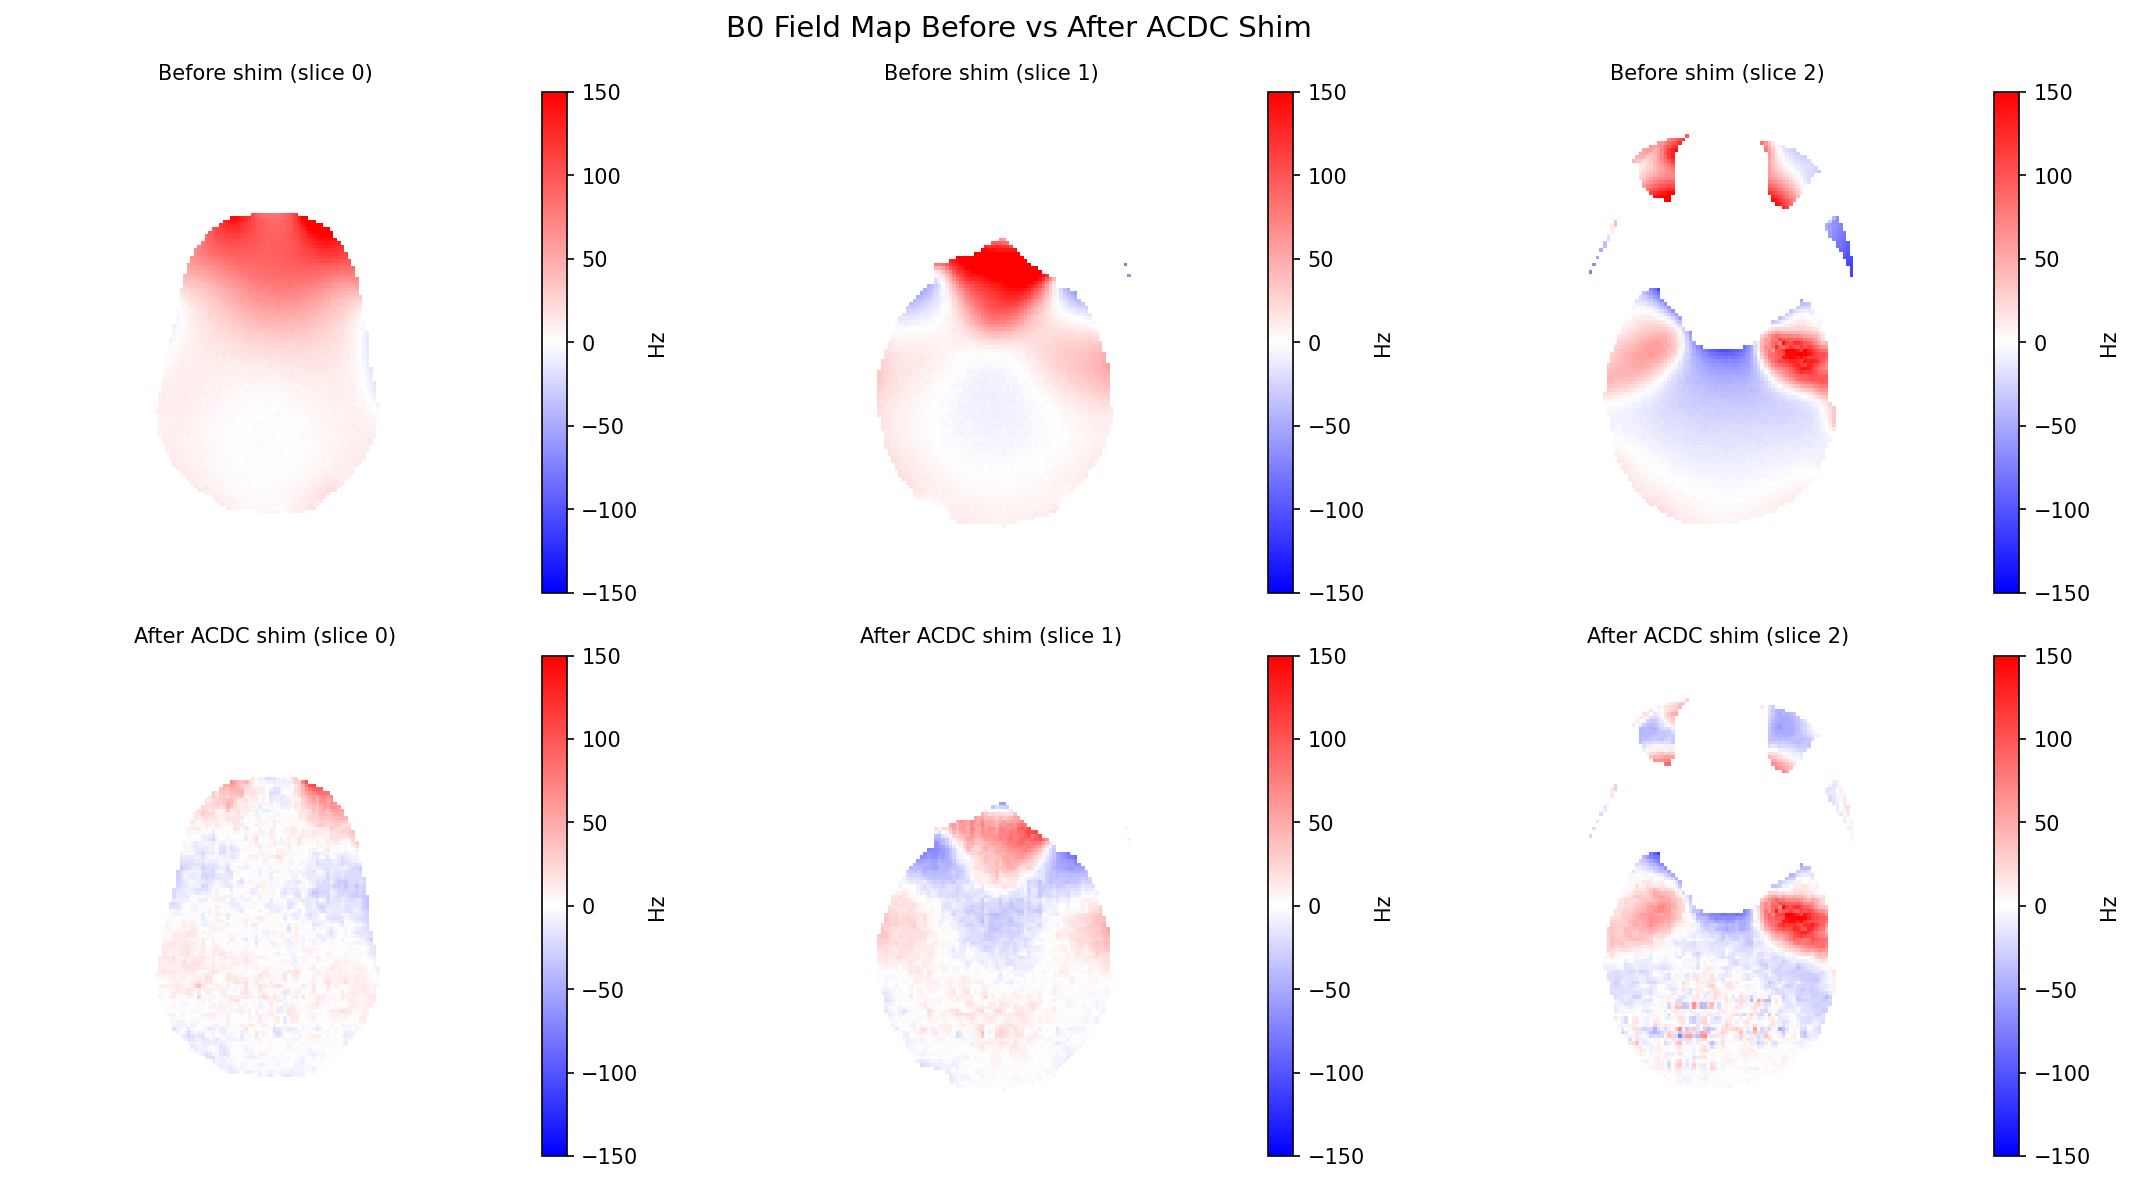

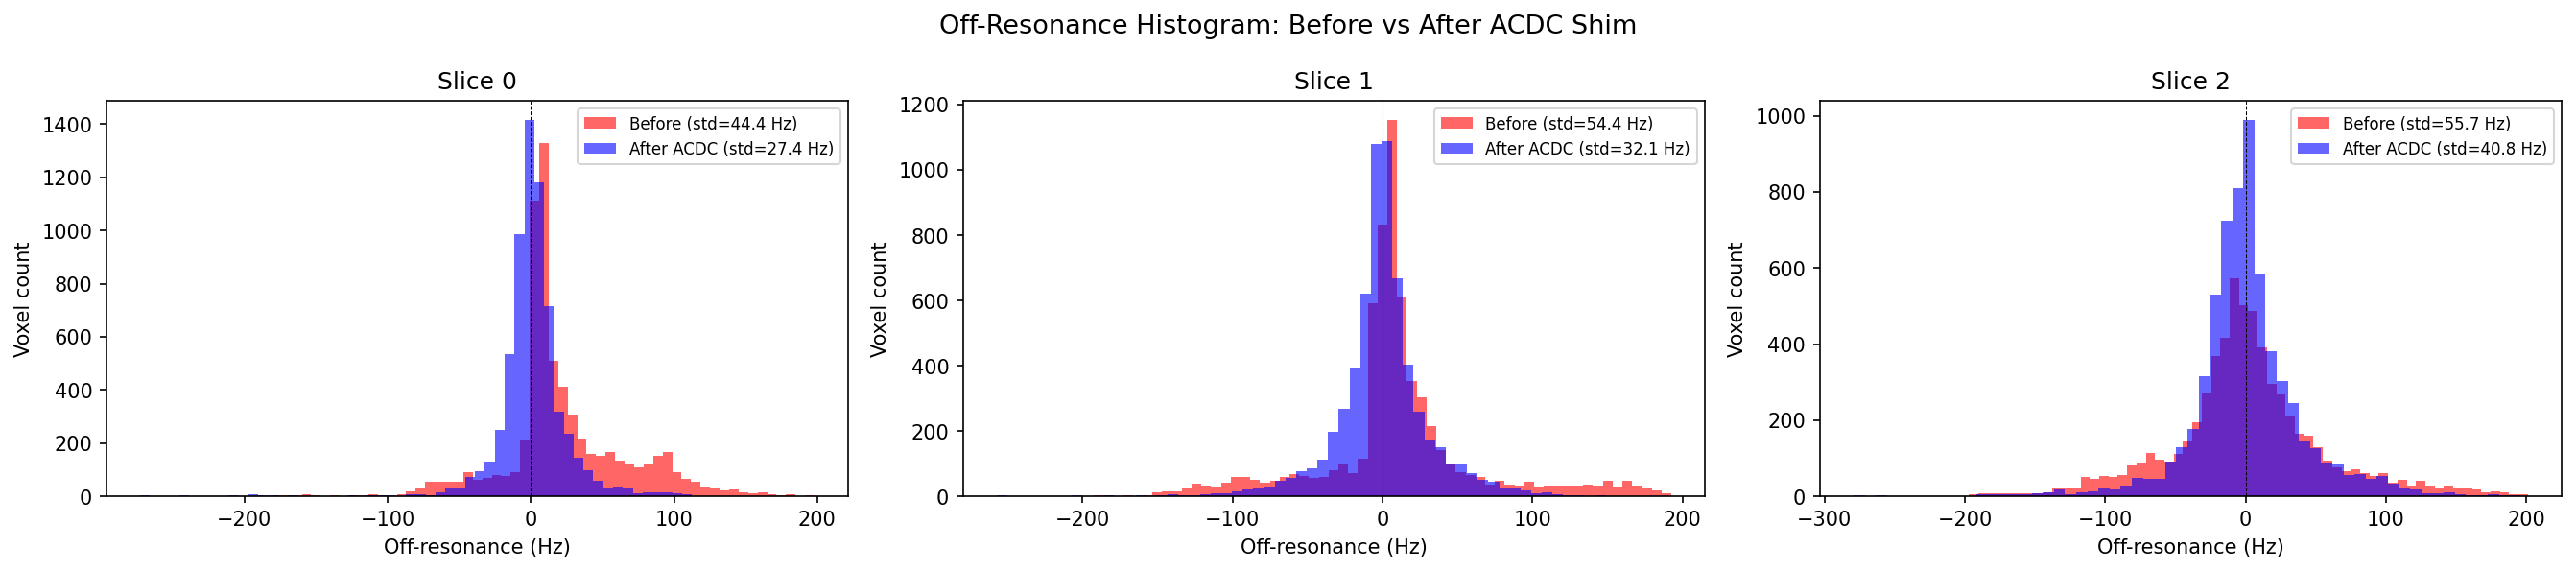


=== Final ACDC Shim Evaluation ===
 Slice | Before std |  After std | Before p95 |  After p95 |  Reduction
-----------------------------------------------------------------------
    0  |    44.40 Hz |    27.39 Hz |   106.46 Hz |    49.17 Hz |    38.3%
    1  |    54.44 Hz |    32.10 Hz |   135.96 Hz |    69.23 Hz |    41.0%
    2  |    55.65 Hz |    40.82 Hz |   123.87 Hz |    91.27 Hz |    26.6%

ACDC shim currents (A):
 Channel Slice0 Slice1 Slice2
     0     +0.24   +0.38   +0.75 
     1     -0.46   +0.10   +0.54 
     2     +3.00   +0.84   -3.00 
     3     +1.62   +0.78   +1.25 
     4     +2.21   +0.22   -0.77 
     5     -0.13   +0.78   +0.25 
     6     -0.18   -0.37   -0.35 
     7     -0.12   +0.45   -0.17 
     8     +0.05   -0.58   +0.06 
     9     +1.61   +0.77   -0.52 
    10     +2.24   +2.78   +0.85 
    11     -2.26   -0.05   +0.46 
    12     +0.05   -0.66   -0.03 
    13     +0.03   +0.62   +0.15 
    14     +0.05   +0.50   +0.40 
    15     +0.03   +0.07   +0.03 

In [49]:
# ======================================================================
# Visualization: B0 field maps before and after ACDC shimming
# ======================================================================
fig, axes = plt.subplots(2, n_slices, figsize=(5 * n_slices, 8), dpi=150)

vmax_show = 150  # Hz colorbar limits

for slc_idx in range(n_slices):
    # m = np.isfinite(b0_field_map_masked[slc_idx])
    m = np.isfinite(b0_field_map_masked_aggressive[slc_idx])

    # Before shim
    b0_plot = np.where(m, b0_field_for_shim[slc_idx], np.nan)
    im0 = axes[0, slc_idx].imshow(b0_plot, cmap='bwr', vmin=-vmax_show, vmax=vmax_show)
    axes[0, slc_idx].set_title(f'Before shim (slice {slc_idx})', fontsize=10)
    axes[0, slc_idx].axis('off')
    plt.colorbar(im0, ax=axes[0, slc_idx], fraction=0.046, pad=0.04, label='Hz')

    # After shim (residual)
    res_plot = np.where(m, residual_field[slc_idx], np.nan)
    im1 = axes[1, slc_idx].imshow(res_plot, cmap='bwr', vmin=-vmax_show, vmax=vmax_show)
    axes[1, slc_idx].set_title(f'After ACDC shim (slice {slc_idx})', fontsize=10)
    axes[1, slc_idx].axis('off')
    plt.colorbar(im1, ax=axes[1, slc_idx], fraction=0.046, pad=0.04, label='Hz')

fig.suptitle('B0 Field Map Before vs After ACDC Shim', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# ======================================================================
# Histogram comparison: off-resonance distribution within mask
# ======================================================================
fig, axes = plt.subplots(1, n_slices, figsize=(6 * n_slices, 4), dpi=150)
if n_slices == 1:
    axes = [axes]

for slc_idx in range(n_slices):
    m = np.isfinite(b0_field_map_masked[slc_idx])
    b0_before = b0_field_for_shim[slc_idx][m].ravel()
    b0_after = residual_field[slc_idx][m].ravel()

    ax = axes[slc_idx]
    ax.hist(b0_before, bins=60, alpha=0.6, color='red', label=f'Before (std={np.std(b0_before):.1f} Hz)')
    ax.hist(b0_after, bins=60, alpha=0.6, color='blue', label=f'After ACDC (std={np.std(b0_after):.1f} Hz)')
    ax.set_xlabel('Off-resonance (Hz)')
    ax.set_ylabel('Voxel count')
    ax.set_title(f'Slice {slc_idx}')
    ax.legend(fontsize=8)
    ax.axvline(0, color='k', ls='--', lw=0.5)

fig.suptitle('Off-Resonance Histogram: Before vs After ACDC Shim', fontsize=13)
plt.tight_layout()
plt.show()

# Print numeric summary
print()
print('=== Final ACDC Shim Evaluation ===')
header = f"{'Slice':>6} | {'Before std':>10} | {'After std':>10} | {'Before p95':>10} | {'After p95':>10} | {'Reduction':>10}"
print(header)
print('-' * len(header))
for slc_idx in range(n_slices):
    m = np.isfinite(b0_field_map_masked[slc_idx])
    b0_before = b0_field_for_shim[slc_idx][m]
    b0_after = residual_field[slc_idx][m]
    bef_std = np.std(b0_before)
    aft_std = np.std(b0_after)
    bef_p95 = np.percentile(np.abs(b0_before), 95)
    aft_p95 = np.percentile(np.abs(b0_after), 95)
    reduction = (1 - aft_std / max(bef_std, 1e-12)) * 100
    print(f'  {slc_idx:3d}  | {bef_std:8.2f} Hz | {aft_std:8.2f} Hz | {bef_p95:8.2f} Hz | {aft_p95:8.2f} Hz | {reduction:7.1f}%')

print()
print('ACDC shim currents (A):')
ch_header = f"{'Channel':>8}"
for slc_idx in range(n_slices):
    ch_header += f" {'Slice':>5}{slc_idx}"
print(ch_header)
for ch_idx in range(n_coils):
    row = f'  {ch_idx:4d}   '
    for slc_idx in range(n_slices):
        row += f'  {acdc_shim_currents[slc_idx, ch_idx]:+5.2f} '
    print(row)